<a href="https://colab.research.google.com/github/Ananthu778/industrial-fault-detection/blob/main/faultdetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries loaded!

📁 STEP 1: UPLOAD YOUR TRAINING DATASET
Please upload your CSV file (Industrial_fault_detection (1).csv)


Saving Industrial_fault_detection (1).csv to Industrial_fault_detection (1).csv

✅ Loaded: 1000 rows, 37 columns

🔧 STEP 2: DATA PREPROCESSING
Raw sensor features: 6
FFT features: 30
Total features: 36

⚠️ Found 10 rows with all zero FFT features
✅ Removed corrupt rows. New shape: (990, 36)

✅ Preprocessing complete! Final shape: (990, 36)

📊 STEP 3: CLASS DISTRIBUTION ANALYSIS

Original class distribution:
   Normal Operation: 717 samples (72.4%)
   Overheating Fault: 90 samples (9.1%)
   Leakage Fault: 94 samples (9.5%)
   Power Fluctuation Fault: 89 samples (9.0%)


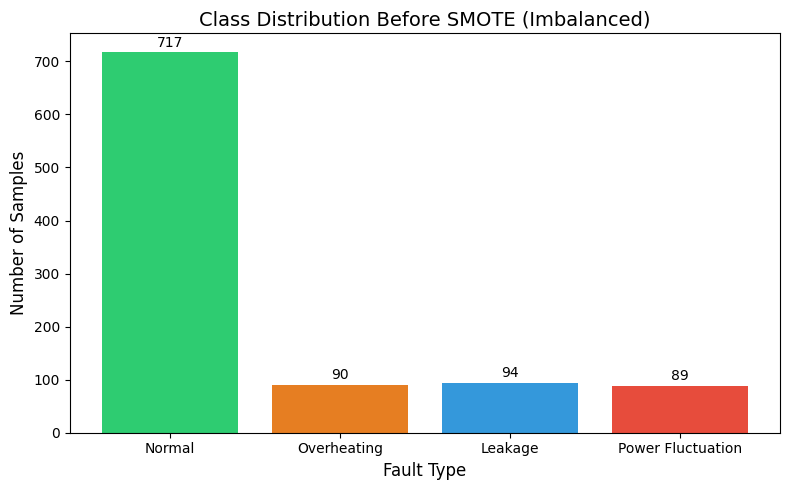


⚖️ STEP 4: APPLYING SMOTE BALANCING

Class distribution AFTER SMOTE:
   Normal Operation: 717 samples
   Overheating Fault: 717 samples
   Leakage Fault: 717 samples
   Power Fluctuation Fault: 717 samples


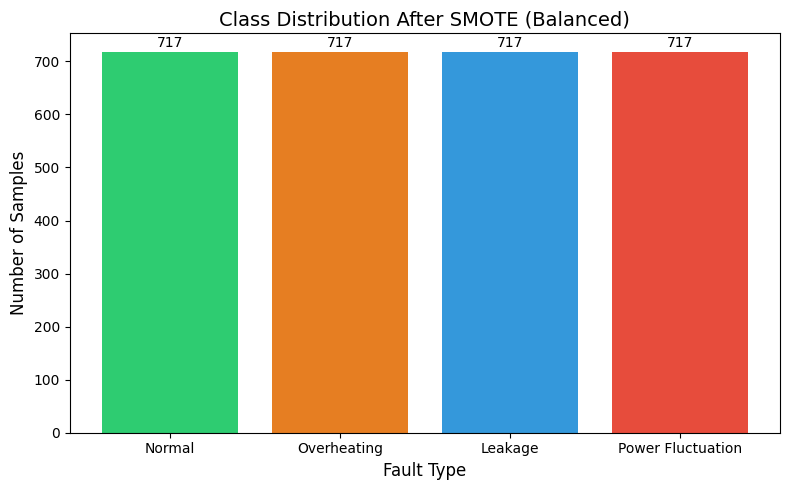


🤖 STEP 5: TRAINING RANDOM FOREST MODEL
Training set: 2294 samples
Test set: 574 samples

Training in progress...
✅ Training complete!

📊 STEP 6: CONFUSION MATRIX ANALYSIS


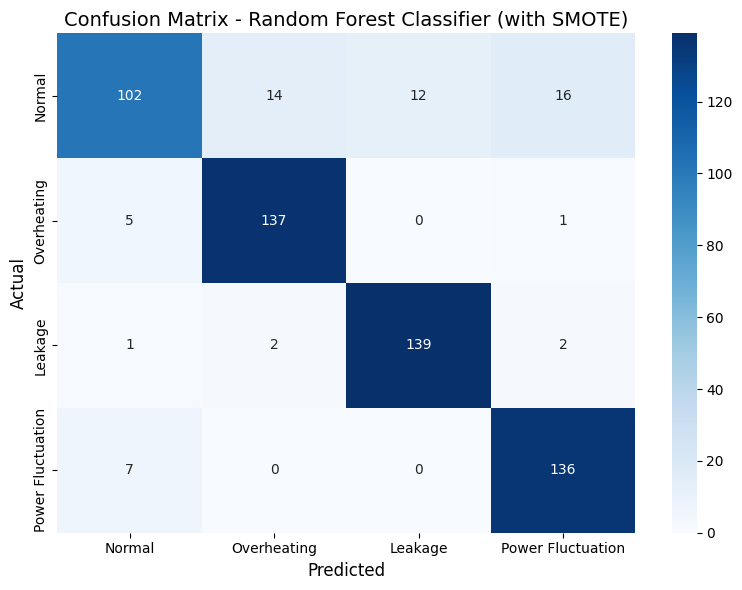


📖 Confusion Matrix Interpretation:
   ✅ Normal correctly classified: 102 out of 144
   ✅ Overheating correctly classified: 137 out of 143
   ✅ Leakage correctly classified: 139 out of 144
   ✅ Power Fluctuation correctly classified: 136 out of 143

📈 STEP 7: CLASSIFICATION REPORT

🎯 Overall Performance Metrics:
   Accuracy: 89.55%
   Precision (macro): 0.8951
   Recall (macro): 0.8957
   F1-Score (macro): 0.8921

📋 Per-Class Performance:
                   precision    recall  f1-score   support

           Normal       0.89      0.71      0.79       144
      Overheating       0.90      0.96      0.93       143
          Leakage       0.92      0.97      0.94       144
Power Fluctuation       0.88      0.95      0.91       143

         accuracy                           0.90       574
        macro avg       0.90      0.90      0.89       574
     weighted avg       0.90      0.90      0.89       574


🔝 STEP 8: FEATURE IMPORTANCE ANALYSIS


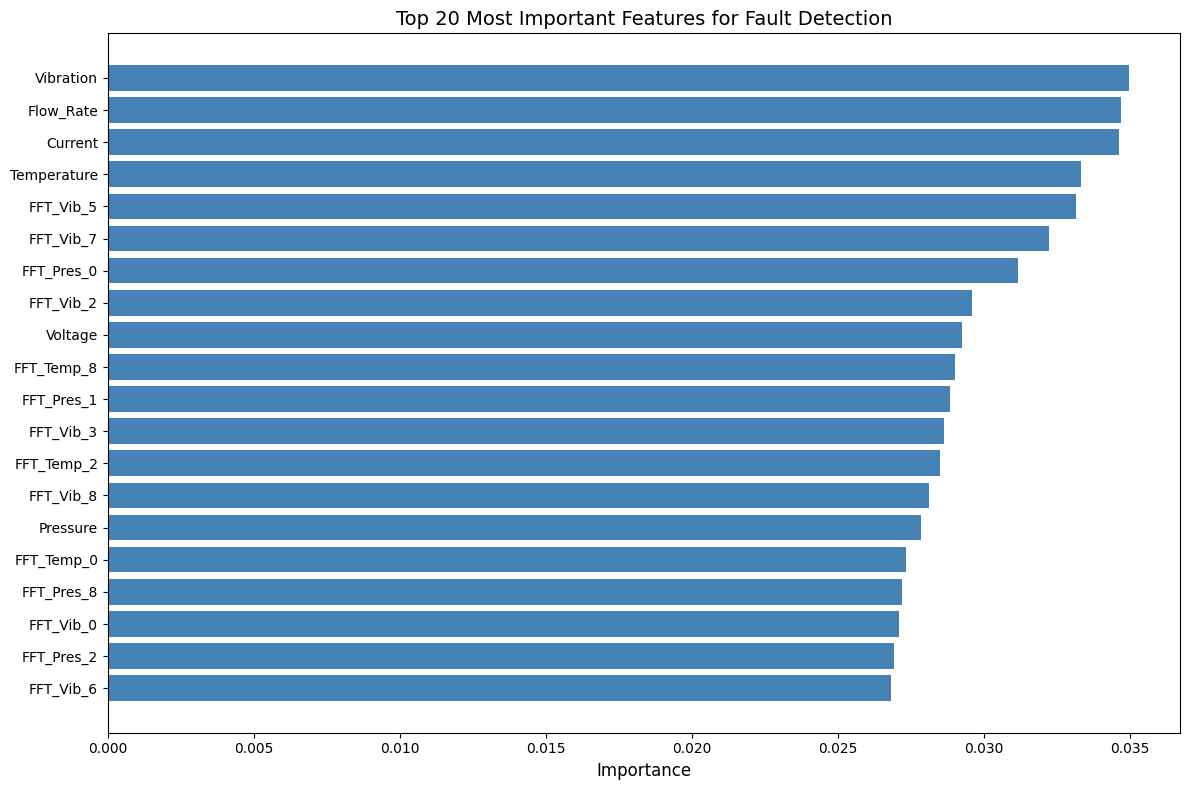


🔍 Top 10 Most Important Features for Fault Detection:
    1. Vibration                      📊 Raw   : 0.0350
    2. Flow_Rate                      📊 Raw   : 0.0347
    3. Current                        📊 Raw   : 0.0346
    4. Temperature                    📊 Raw   : 0.0333
    5. FFT_Vib_5                      🔊 FFT   : 0.0331
    6. FFT_Vib_7                      🔊 FFT   : 0.0322
    7. FFT_Pres_0                     🔊 FFT   : 0.0312
    8. FFT_Vib_2                      🔊 FFT   : 0.0296
    9. Voltage                        📊 Raw   : 0.0292
   10. FFT_Temp_8                     🔊 FFT   : 0.0290

📌 Key Finding: 5/10 top features are FFT features
   → Frequency-domain analysis is crucial for fault detection!

📊 STEP 9: TRAINING DATA SIGNAL ANALYSIS


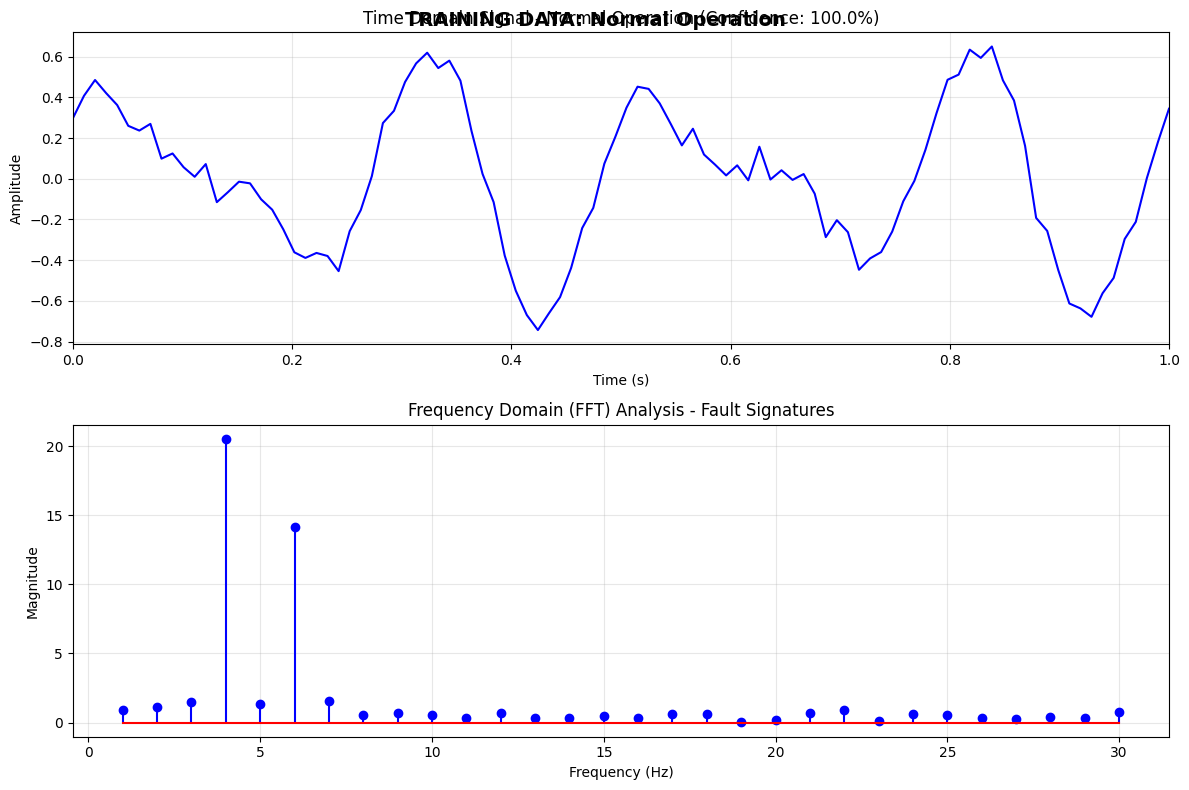

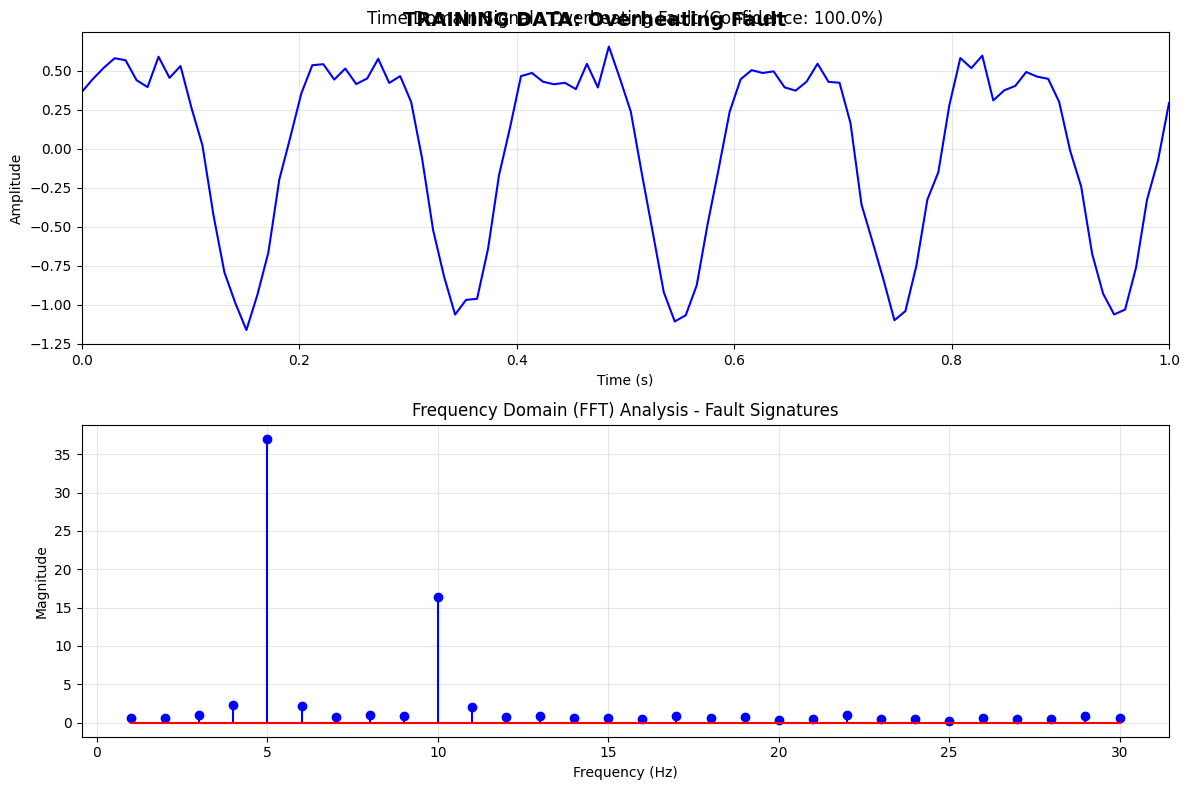

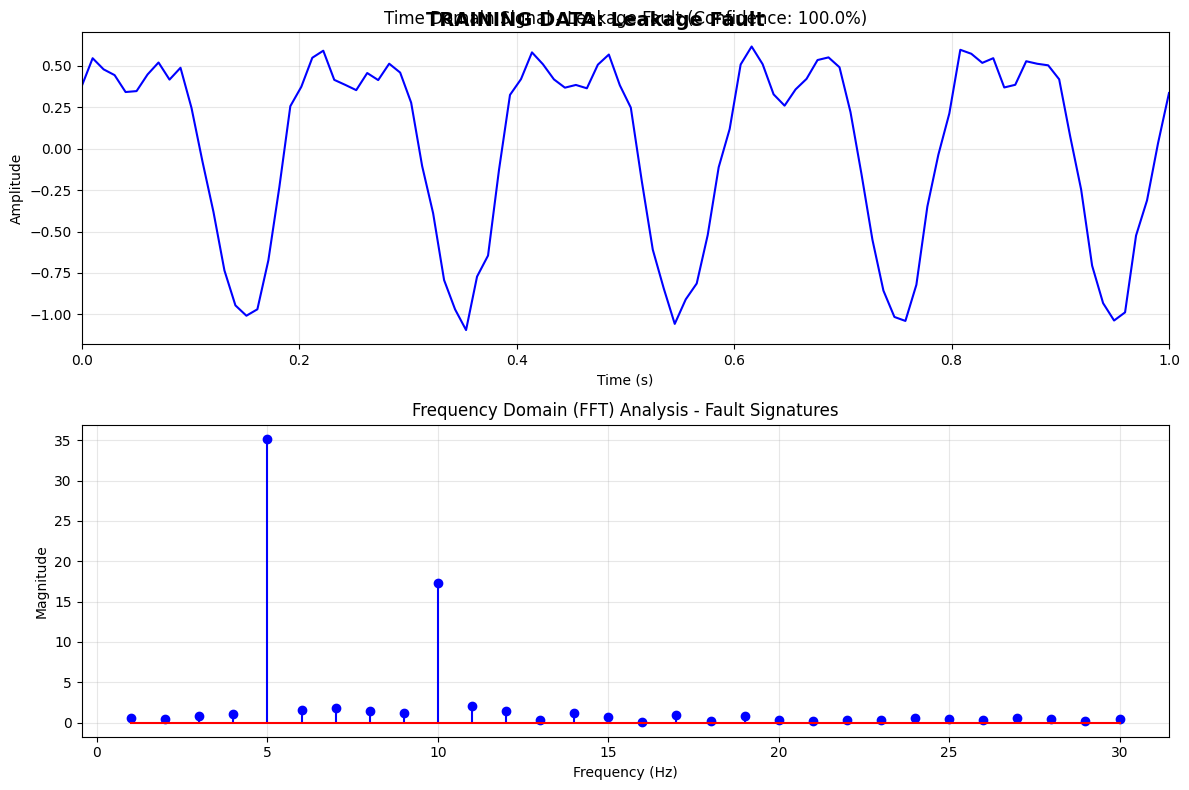

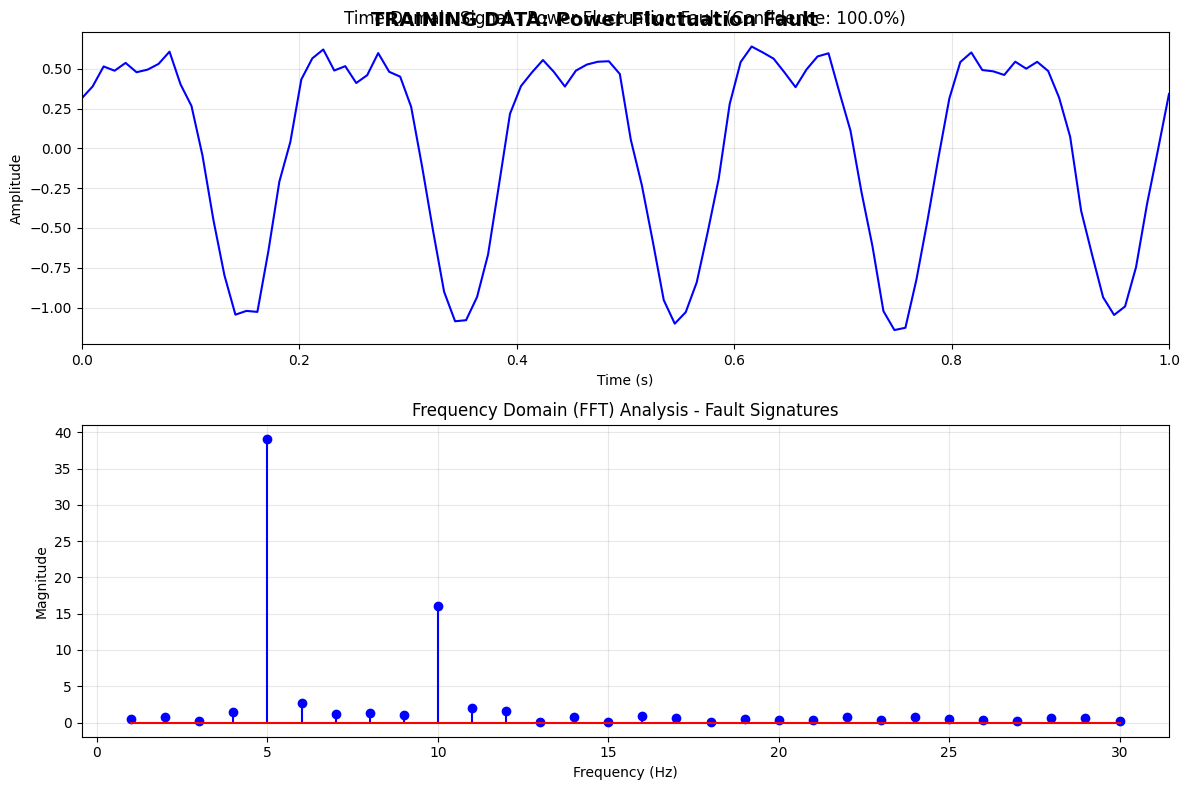


💾 STEP 10: SAVING MODEL
✅ Model saved successfully!

🎯 SYSTEM READY!

✅ Model Accuracy: 89.55%
✅ F1-Macro Score: 0.8921

📊 Fault Categories:
   0 → Normal Operation
   1 → Overheating Fault
   2 → Leakage Fault
   3 → Power Fluctuation Fault

✅ Ready to predict faults with signal visualization!

🔧 INDUSTRIAL FAULT DETECTION SYSTEM

🎯 Model Accuracy: 89.55%
📊 F1-Score: 0.8921

📋 MAIN MENU:
   [1] ✏️  Manual Entry (with signal graphs)
   [2] 📁 CSV Batch Prediction
   [3] 🧪 Test Scenarios
   [4] 📊 View Confusion Matrix & Report
   [5] ❌ Exit


In [ ]:
# INDUSTRIAL FAULT DETECTION SYSTEM

!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
import joblib

print("✅ All libraries loaded!")

# FAULT CATEGORIES

fault_names = {
    0: "Normal Operation",
    1: "Overheating Fault",
    2: "Leakage Fault",
    3: "Power Fluctuation Fault"
}

fault_names_display = {
    0: "✅ NORMAL OPERATION - No fault detected",
    1: "🔥 OVERHEATING FAULT - Check cooling system",
    2: "💧 LEAKAGE FAULT - Inspect pipes and seals",
    3: "⚡ POWER FLUCTUATION - Check voltage regulator"
}

fault_icons = {0: "🟢", 1: "🔥", 2: "💧", 3: "⚡"}

fault_risk = {
    0: "🟢 LOW - Continue normal operation",
    1: "🟠 MEDIUM - Schedule cooling system inspection",
    2: "🟡 MEDIUM-HIGH - Check for leaks immediately",
    3: "🔴 HIGH - Inspect power supply urgently"
}

fault_recommendations = {
    0: "Regular monitoring is sufficient. No action needed.",
    1: "Check cooling system, reduce load, inspect thermal sensors.",
    2: "Inspect pipes, valves, and seals for leaks. Check pump efficiency.",
    3: "Check voltage regulator, UPS system, and power quality."
}

# SIGNAL VISUALIZATION FUNCTIONS

def generate_time_domain_signal(values, sample_rate=100):
    """Generate a synthetic time domain signal from feature values"""
    t = np.linspace(0, 1, sample_rate)
    # Different signal patterns for different fault types based on values
    if values[0] > 80:  # High temperature - overheating pattern
        signal = (values[0] / 100) * np.sin(2 * np.pi * 8 * t) + \
                 (values[1] / 10) * np.sin(2 * np.pi * 12 * t)
    elif values[2] < 90:  # Low pressure - leakage pattern
        signal = (values[0] / 100) * np.sin(2 * np.pi * 4 * t) + \
                 (values[2] / 200) * np.cos(2 * np.pi * 6 * t)
    elif values[5] < 210 or values[5] > 230:  # Voltage issue - power fluctuation
        signal = (values[0] / 100) * np.sin(2 * np.pi * 5 * t) + \
                 0.3 * np.sin(2 * np.pi * 25 * t)  # High frequency noise
    else:  # Normal operation
        signal = (values[0] / 100) * np.sin(2 * np.pi * 5 * t) + \
                 (values[1] / 10) * np.cos(2 * np.pi * 10 * t)

    noise = np.random.normal(0, 0.05, len(signal))
    signal = signal + noise
    return t, signal

def plot_combined_signals(parameters, fault_name, confidence):
    """Plot both time domain and FFT together"""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    values = list(parameters.values())[:6]
    t, signal = generate_time_domain_signal(values)

    # Time Domain
    axes[0].plot(t, signal, 'b-', linewidth=1.5)
    axes[0].set_xlabel('Time (s)', fontsize=10)
    axes[0].set_ylabel('Amplitude', fontsize=10)
    axes[0].set_title(f'Time Domain Signal - {fault_name} (Confidence: {confidence:.1f}%)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1)

    # FFT
    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(len(signal), 1/100)
    positive_idx = fft_freq > 0
    axes[1].stem(fft_freq[positive_idx][:30], np.abs(fft_vals[positive_idx][:30]),
                 linefmt='b-', markerfmt='bo', basefmt='r-')
    axes[1].set_xlabel('Frequency (Hz)', fontsize=10)
    axes[1].set_ylabel('Magnitude', fontsize=10)
    axes[1].set_title('Frequency Domain (FFT) Analysis - Fault Signatures', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# UPLOAD AND PREPROCESS DATA

print("\n" + "="*70)
print("📁 STEP 1: UPLOAD YOUR TRAINING DATASET")
print("="*70)
print("Please upload your CSV file (Industrial_fault_detection (1).csv)")

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# DATA PREPROCESSING

print("\n" + "="*70)
print("🔧 STEP 2: DATA PREPROCESSING")
print("="*70)

# Separate features and target
feature_cols = [col for col in df.columns if col != 'Fault_Type']
X = df[feature_cols].copy()
y = df['Fault_Type'].copy()

# Identify FFT columns
fft_cols = [col for col in feature_cols if col.startswith('FFT_')]
raw_cols = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage']

print(f"Raw sensor features: {len(raw_cols)}")
print(f"FFT features: {len(fft_cols)}")
print(f"Total features: {len(feature_cols)}")

# Remove rows with all zero FFT
zero_fft_rows = (X[fft_cols] == 0).all(axis=1).sum()
if zero_fft_rows > 0:
    print(f"\n⚠️ Found {zero_fft_rows} rows with all zero FFT features")
    mask = ~(X[fft_cols] == 0).all(axis=1)
    X = X[mask]
    y = y[mask]
    print(f"✅ Removed corrupt rows. New shape: {X.shape}")

# Handle missing values
X = X.fillna(X.mean())
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# Store mean FFT values for predictions
mean_fft_values = {}
for col in fft_cols:
    mean_fft_values[col] = X[col].mean()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Preprocessing complete! Final shape: {X_scaled.shape}")

# CLASS DISTRIBUTION (BEFORE SMOTE)

print("\n" + "="*70)
print("📊 STEP 3: CLASS DISTRIBUTION ANALYSIS")
print("="*70)

fault_counts = y.value_counts().sort_index()

print("\nOriginal class distribution:")
for ft, count in fault_counts.items():
    print(f"   {fault_names[ft]}: {count} samples ({count/len(y)*100:.1f}%)")

# Plot class distribution before SMOTE
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e67e22', '#3498db', '#e74c3c']
bars = plt.bar(fault_counts.index, fault_counts.values, color=colors)
plt.xlabel('Fault Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution Before SMOTE (Imbalanced)', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'])
for bar, count in zip(bars, fault_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# APPLY SMOTE TO BALANCE CLASSES

print("\n" + "="*70)
print("⚖️ STEP 4: APPLYING SMOTE BALANCING")
print("="*70)

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

balanced_counts = pd.Series(y_balanced).value_counts().sort_index()
print("\nClass distribution AFTER SMOTE:")
for ft, count in balanced_counts.items():
    print(f"   {fault_names[ft]}: {count} samples")

# Plot class distribution after SMOTE
plt.figure(figsize=(8, 5))
bars = plt.bar(balanced_counts.index, balanced_counts.values, color=colors)
plt.xlabel('Fault Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution After SMOTE (Balanced)', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'])
for bar, count in zip(bars, balanced_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# TRAIN-TEST SPLIT

print("\n" + "="*70)
print("🤖 STEP 5: TRAINING RANDOM FOREST MODEL")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

print("\nTraining in progress...")
rf_model.fit(X_train, y_train)
print("✅ Training complete!")

# CONFUSION MATRIX

print("\n" + "="*70)
print("📊 STEP 6: CONFUSION MATRIX ANALYSIS")
print("="*70)

y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'],
            yticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'])
plt.title('Confusion Matrix - Random Forest Classifier (with SMOTE)', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Print confusion matrix interpretation
print("\n📖 Confusion Matrix Interpretation:")
print(f"   ✅ Normal correctly classified: {cm[0][0]} out of {cm[0].sum()}")
print(f"   ✅ Overheating correctly classified: {cm[1][1]} out of {cm[1].sum()}")
print(f"   ✅ Leakage correctly classified: {cm[2][2]} out of {cm[2].sum()}")
print(f"   ✅ Power Fluctuation correctly classified: {cm[3][3]} out of {cm[3].sum()}")

# CLASSIFICATION REPORT

print("\n" + "="*70)
print("📈 STEP 7: CLASSIFICATION REPORT")
print("="*70)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')

print(f"\n🎯 Overall Performance Metrics:")
print(f"   Accuracy: {accuracy*100:.2f}%")
print(f"   Precision (macro): {precision_macro:.4f}")
print(f"   Recall (macro): {recall_macro:.4f}")
print(f"   F1-Score (macro): {f1_macro:.4f}")

print("\n📋 Per-Class Performance:")
print(classification_report(y_test, y_pred,
                           target_names=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation']))

# FEATURE IMPORTANCE

print("\n" + "="*70)
print("🔝 STEP 8: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_cols))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue')
plt.yticks(range(top_n), [feature_cols[i] for i in indices[:top_n]][::-1])
plt.xlabel('Importance', fontsize=12)
plt.title(f'Top {top_n} Most Important Features for Fault Detection', fontsize=14)
plt.tight_layout()
plt.show()

print("\n🔍 Top 10 Most Important Features for Fault Detection:")
for i in range(min(10, len(feature_cols))):
    fft_mark = "🔊 FFT" if feature_cols[indices[i]].startswith('FFT_') else "📊 Raw"
    print(f"   {i+1:2d}. {feature_cols[indices[i]]:30s} {fft_mark:8s}: {importances[indices[i]]:.4f}")

# Count FFT vs Raw in top 10
fft_count = sum(1 for i in range(min(10, len(feature_cols))) if feature_cols[indices[i]].startswith('FFT_'))
print(f"\n📌 Key Finding: {fft_count}/10 top features are FFT features")
print("   → Frequency-domain analysis is crucial for fault detection!")

# TRAINING DATA SIGNAL VISUALIZATION

print("\n" + "="*70)
print("📊 STEP 9: TRAINING DATA SIGNAL ANALYSIS")
print("="*70)

for fault_type in [0, 1, 2, 3]:
    samples = df[df['Fault_Type'] == fault_type]
    if len(samples) > 0:
        sample = samples.iloc[0]
        params = {
            'Temperature': sample['Temperature'],
            'Vibration': sample['Vibration'],
            'Pressure': sample['Pressure'],
            'Flow_Rate': sample['Flow_Rate'],
            'Current': sample['Current'],
            'Voltage': sample['Voltage']
        }
        fig = plot_combined_signals(params, fault_names[fault_type], 100)
        plt.suptitle(f'TRAINING DATA: {fault_names[fault_type]}', fontsize=14, fontweight='bold')
        plt.show()

# SAVE MODEL

print("\n" + "="*70)
print("💾 STEP 10: SAVING MODEL")
print("="*70)

joblib.dump(rf_model, 'fault_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(mean_fft_values, 'mean_fft_values.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("✅ Model saved successfully!")

# PREDICTION FUNCTION

def predict_with_signals(temp, vib, pres, flow, curr, volt):
    """Predict fault and display time domain + FFT graphs"""

    params = {
        'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
        'Flow_Rate': flow, 'Current': curr, 'Voltage': volt
    }

    # Create input with all features
    input_dict = {
        'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
        'Flow_Rate': flow, 'Current': curr, 'Voltage': volt
    }

    for col in fft_cols:
        input_dict[col] = mean_fft_values[col]

    input_df = pd.DataFrame([input_dict])
    input_df = input_df[feature_cols]
    input_scaled = scaler.transform(input_df)

    prediction = rf_model.predict(input_scaled)[0]
    probabilities = rf_model.predict_proba(input_scaled)[0]
    confidence = probabilities[prediction] * 100

    print("\n" + "="*70)
    print("🔍 PREDICTION RESULT")
    print("="*70)
    print(f"\n📊 INPUT VALUES:")
    print(f"   Temperature: {temp}°C", "⚠️ HIGH" if temp > 80 else "✅ NORMAL" if temp < 80 else "✅ NORMAL")
    print(f"   Vibration: {vib}", "⚠️ HIGH" if vib > 3.5 else "✅ NORMAL")
    print(f"   Pressure: {pres}", "⚠️ LOW" if pres < 90 else "⚠️ HIGH" if pres > 105 else "✅ NORMAL")
    print(f"   Flow Rate: {flow}", "⚠️ LOW" if flow < 8 else "✅ NORMAL")
    print(f"   Current: {curr} A", "⚠️ HIGH" if curr > 18 else "✅ NORMAL")
    print(f"   Voltage: {volt} V", "⚠️ LOW" if volt < 210 else "⚠️ HIGH" if volt > 230 else "✅ NORMAL")

    print(f"\n{fault_icons[prediction]} {fault_names_display[prediction]}")
    print(f"📈 Confidence: {confidence:.1f}%")
    print(f"🛡️ Risk Level: {fault_risk[prediction]}")
    print(f"💡 Recommendation: {fault_recommendations[prediction]}")

    print("\n📉 Probability Distribution:")
    labels = ["Normal", "Overheating", "Leakage", "Power Fluctuation"]
    for i, prob in enumerate(probabilities):
        bar = "█" * int(prob * 40)
        print(f"   {labels[i]:20s}: {prob*100:5.1f}% {bar}")

    fig = plot_combined_signals(params, fault_names[prediction], confidence)
    plt.suptitle(f'PREDICTED: {fault_names[prediction]} (Confidence: {confidence:.1f}%)',
                 fontsize=14, fontweight='bold')
    plt.show()

    return prediction, probabilities

# BATCH PREDICTION FROM CSV

def batch_prediction():
    print("\n" + "="*70)
    print("📁 BATCH PREDICTION FROM CSV")
    print("="*70)

    print("\n📋 CSV FORMAT (6 columns):")
    print("   Temperature,Vibration,Pressure,Flow_Rate,Current,Voltage")
    print("   75.0,3.0,100.0,10.0,15.0,220.0")
    print("\n💡 Fault Indicators:")
    print("   • Overheating: Temp>80°C, Current>20A")
    print("   • Leakage: Pressure<90, Flow Rate<8")
    print("   • Power Fluctuation: Voltage<210 or >230")

    print("\n📁 Upload your CSV file...")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No file uploaded")
        return

    filename = list(uploaded.keys())[0]
    new_data = pd.read_csv(filename)

    print(f"\n✅ Loaded {len(new_data)} samples")

    results = []
    for i in range(len(new_data)):
        temp = new_data['Temperature'].iloc[i]
        vib = new_data['Vibration'].iloc[i]
        pres = new_data['Pressure'].iloc[i]
        flow = new_data['Flow_Rate'].iloc[i]
        curr = new_data['Current'].iloc[i]
        volt = new_data['Voltage'].iloc[i]

        print(f"\n{'='*60}")
        print(f"📊 Sample #{i+1}")
        print(f"{'='*60}")

        pred, probs = predict_with_signals(temp, vib, pres, flow, curr, volt)

        results.append({
            'ID': i+1,
            'Temperature': temp,
            'Vibration': vib,
            'Pressure': pres,
            'Prediction': fault_names[pred],
            'Confidence': f"{probs[pred]*100:.1f}%"
        })

    # Summary
    print("\n" + "="*70)
    print("📊 SUMMARY RESULTS")
    print("="*70)
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    save = input("\n💾 Save results to CSV? (yes/no): ").lower()
    if save == 'yes':
        results_df.to_csv('batch_results.csv', index=False)
        files.download('batch_results.csv')
        print("✅ Results saved!")

# MANUAL PREDICTION

def manual_prediction():
    print("\n" + "="*70)
    print("✏️ MANUAL PREDICTION MODE")
    print("="*70)

    print("\n📋 NORMAL OPERATING RANGES:")
    print("   Temperature: 70-80°C | Vibration: 2.5-3.5")
    print("   Pressure: 90-105 | Flow Rate: 8-12")
    print("   Current: 12-18 A | Voltage: 210-230 V")

    print("\n💡 FAULT INDICATORS:")
    print("   🔥 Overheating: Temp > 80°C, Current > 20A")
    print("   💧 Leakage: Pressure < 90, Flow Rate < 8")
    print("   ⚡ Power Fluctuation: Voltage < 210 or > 230")

    count = 0
    while True:
        count += 1
        print(f"\n📊 MACHINE #{count}")
        print("-"*40)

        try:
            temp = float(input("   Temperature (°C): "))
            vib = float(input("   Vibration: "))
            pres = float(input("   Pressure: "))
            flow = float(input("   Flow Rate: "))
            curr = float(input("   Current (A): "))
            volt = float(input("   Voltage (V): "))

            predict_with_signals(temp, vib, pres, flow, curr, volt)

            another = input("\n🔁 Predict another machine? (yes/no): ").lower()
            if another != 'yes':
                break

        except ValueError:
            print("❌ Invalid input! Please enter numeric values.")


# TEST SCENARIOS

def test_scenarios():
    print("\n" + "="*70)
    print("🧪 TEST SCENARIOS")
    print("="*70)

    test_cases = [
        {"name": "🟢 NORMAL OPERATION", "temp": 75, "vib": 3.0, "pres": 100, "flow": 10, "curr": 15, "volt": 220},
        {"name": "🔥 OVERHEATING FAULT", "temp": 85, "vib": 4.0, "pres": 102, "flow": 11, "curr": 24, "volt": 220},
        {"name": "💧 LEAKAGE FAULT", "temp": 74, "vib": 3.2, "pres": 82, "flow": 6.5, "curr": 16, "volt": 218},
        {"name": "⚡ POWER FLUCTUATION", "temp": 76, "vib": 3.3, "pres": 100, "flow": 10, "curr": 14, "volt": 205},
        {"name": "🔥 SEVERE OVERHEATING", "temp": 90, "vib": 4.5, "pres": 108, "flow": 12, "curr": 28, "volt": 225},
        {"name": "💧 SEVERE LEAKAGE", "temp": 73, "vib": 3.0, "pres": 75, "flow": 5, "curr": 15, "volt": 215},
        {"name": "⚡ SEVERE POWER ISSUE", "temp": 77, "vib": 3.4, "pres": 101, "flow": 10.5, "curr": 13, "volt": 195},
    ]

    for case in test_cases:
        print(f"\n{'='*60}")
        print(f"Testing: {case['name']}")
        print(f"{'='*60}")
        predict_with_signals(case['temp'], case['vib'], case['pres'],
                            case['flow'], case['curr'], case['volt'])

# MAIN MENU

def main_menu():
    while True:
        print("\n" + "="*70)
        print("🔧 INDUSTRIAL FAULT DETECTION SYSTEM")
        print("="*70)
        print(f"\n🎯 Model Accuracy: {accuracy*100:.2f}%")
        print(f"📊 F1-Score: {f1_macro:.4f}")
        print("\n📋 MAIN MENU:")
        print("   [1] ✏️  Manual Entry (with signal graphs)")
        print("   [2] 📁 CSV Batch Prediction")
        print("   [3] 🧪 Test Scenarios")
        print("   [4] 📊 View Confusion Matrix & Report")
        print("   [5] ❌ Exit")

        choice = input("\n👉 Enter choice (1-5): ").strip()

        if choice == '1':
            manual_prediction()
        elif choice == '2':
            batch_prediction()
        elif choice == '3':
            test_scenarios()
        elif choice == '4':
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'],
                        yticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'])
            plt.title('Confusion Matrix', fontsize=14)
            plt.show()
            print(f"\n📊 Performance Summary:")
            print(f"   Accuracy: {accuracy*100:.2f}%")
            print(f"   F1-Score: {f1_macro:.4f}")
            print(f"   Precision: {precision_macro:.4f}")
            print(f"   Recall: {recall_macro:.4f}")
            print("\n📋 Classification Report:")
            print(classification_report(y_test, y_pred,
                                       target_names=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation']))
            input("\nPress Enter to continue...")
        elif choice == '5':
            print("\n" + "="*70)
            print("✅ Thank you for using the Fault Detection System!")
            print("👋 Goodbye!")
            print("="*70)
            break
        else:
            print("❌ Invalid choice. Please enter 1-5.")

# RUN THE SYSTEM

print("\n" + "="*70)
print("🎯 SYSTEM READY!")
print("="*70)
print(f"\n✅ Model Accuracy: {accuracy*100:.2f}%")
print(f"✅ F1-Macro Score: {f1_macro:.4f}")
print("\n📊 Fault Categories:")
print("   0 → Normal Operation")
print("   1 → Overheating Fault")
print("   2 → Leakage Fault")
print("   3 → Power Fluctuation Fault")
print("\n✅ Ready to predict faults with signal visualization!")

main_menu()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 8.0 MB/s eta 0:00:00
✅ All libraries loaded!

📁 STEP 1: UPLOAD YOUR TRAINING DATASET
Please upload your CSV file (Industrial_fault_detection (1).csv)


Saving Industrial_fault_detection (1).csv to Industrial_fault_detection (1).csv

✅ Loaded: 1000 rows, 37 columns

📊 LOADED DATA PREVIEW

📁 File Name: Industrial_fault_detection (1).csv
📏 Dataset Shape: 1000 rows × 37 columns

──────────────────────────────────────────────────────────────────────
📋 FIRST 5 ROWS (Preview):
──────────────────────────────────────────────────────────────────────
   Temperature  Vibration   Pressure  Flow_Rate    Current     Voltage  \
0    42.000000   1.980000  56.775766   6.184385  12.409519  215.762403   
1    62.529168   2.573668  76.159843   8.279230  14.906390  215.465859   
2    77.295015   3.243491  92.372614   9.172789  15.054051  202.043568   
3    76.564164   3.142904  94.149558  13.775375  16.417891  216.699098   
4    78.281641   3.139960  94.441006  11.113106  10.899425  227.328291   

   FFT_Temp_0  FFT_Vib_0  FFT_Pres_0  FFT_Temp_1  ...  FFT_Temp_7  FFT_Vib_7  \
0  772.403056  32.436537  971.805333    3.760640  ...   22.088538   1.289962   
1

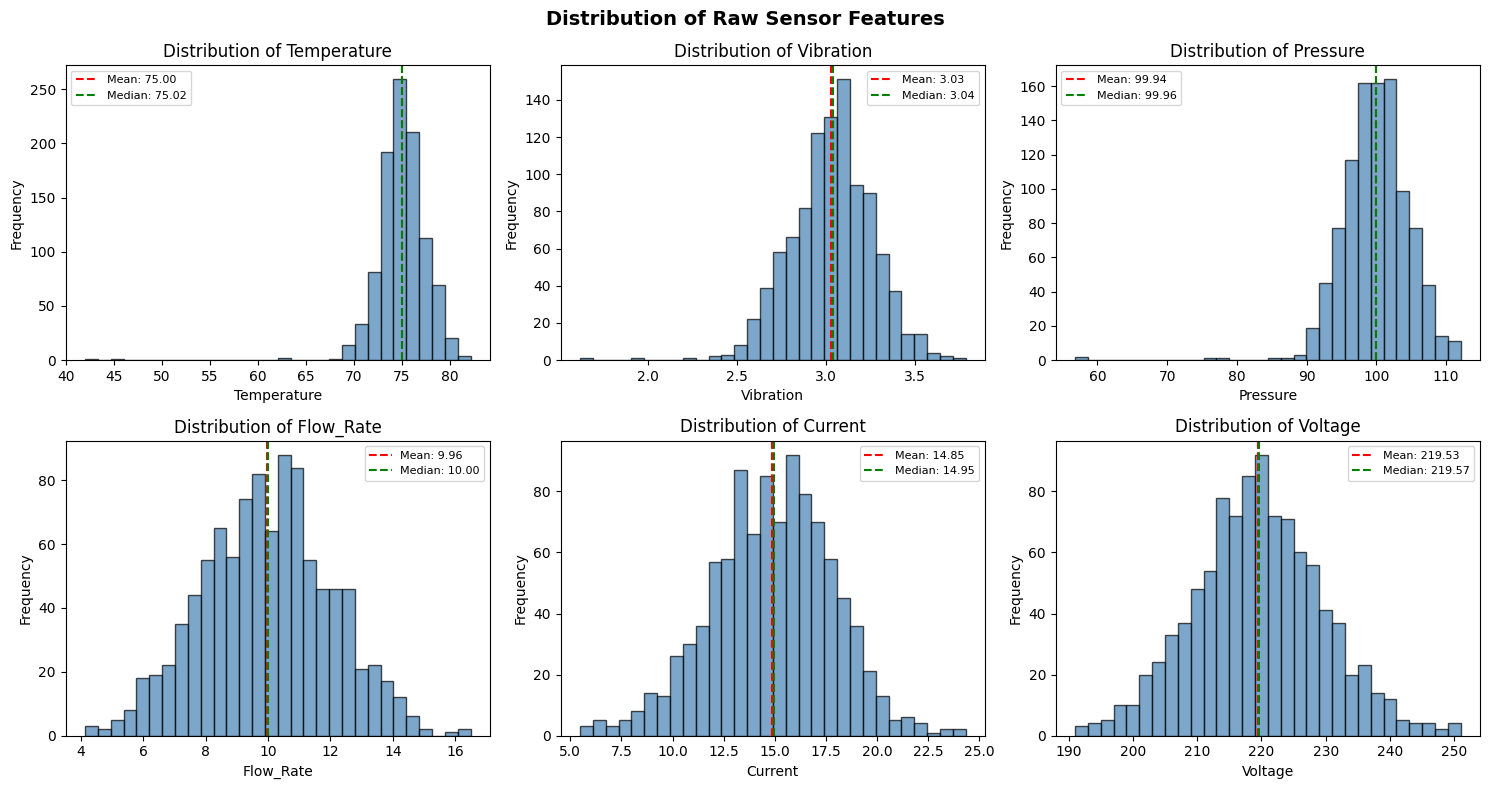


📊 PLOTTING CORRELATION HEATMAP


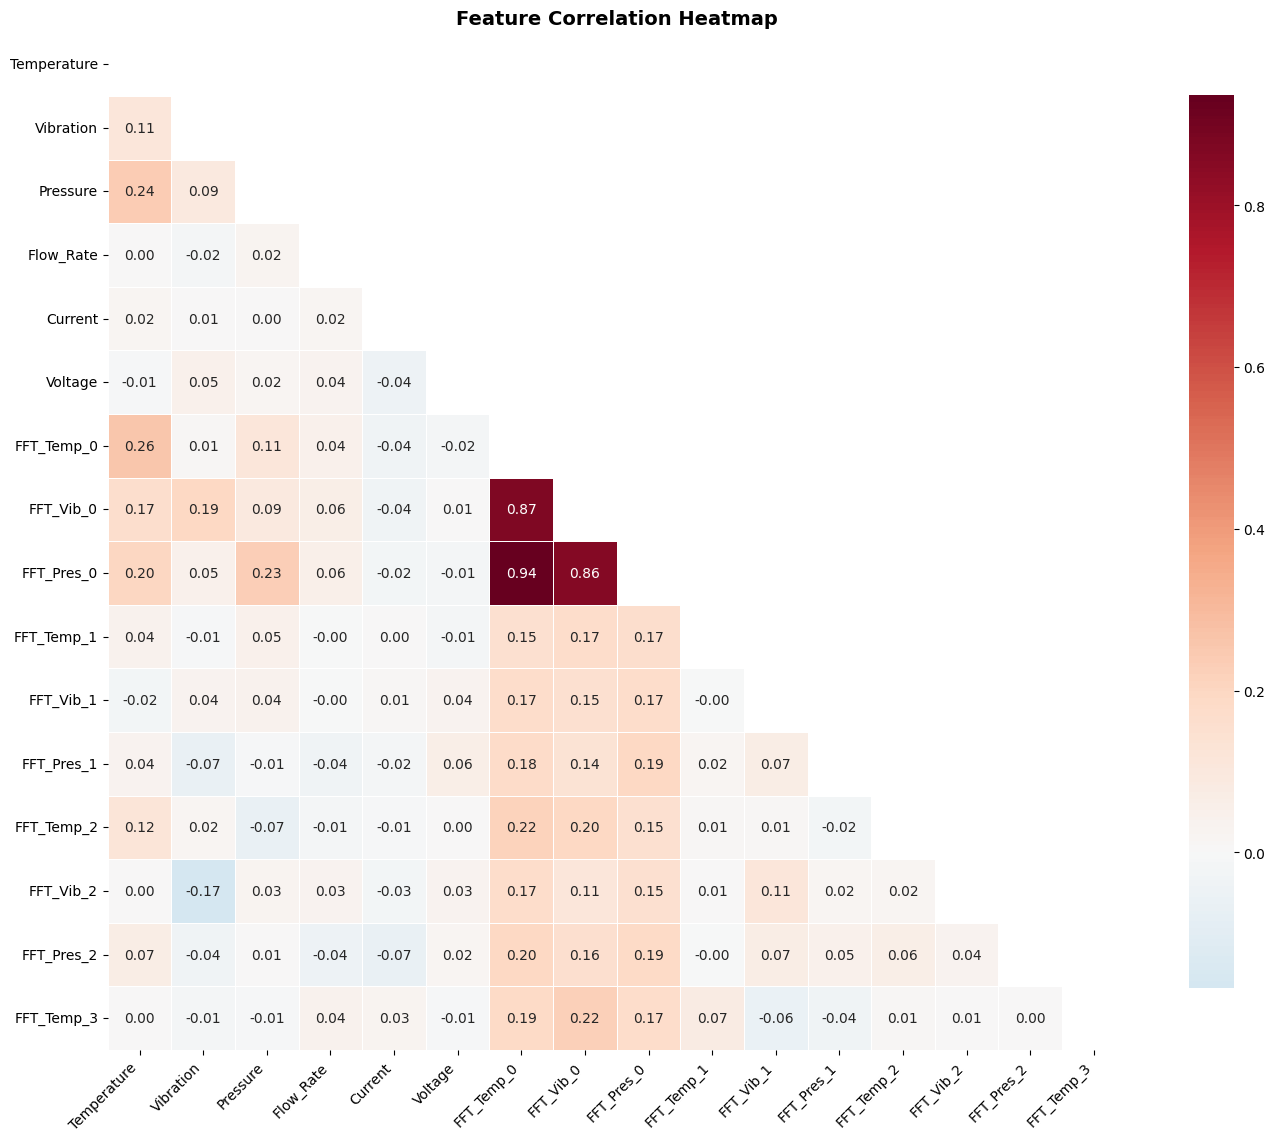


🔧 STEP 2: DATA PREPROCESSING
Raw sensor features: 6
FFT features: 30
Total features: 36

⚠️ Found 10 rows with all zero FFT features
✅ Removed corrupt rows. New shape: (990, 36)

✅ Preprocessing complete! Final shape: (990, 36)

📊 STEP 3: CLASS DISTRIBUTION ANALYSIS

Original class distribution:
   Normal Operation: 717 samples (72.4%)
   Overheating Fault: 90 samples (9.1%)
   Leakage Fault: 94 samples (9.5%)
   Power Fluctuation Fault: 89 samples (9.0%)


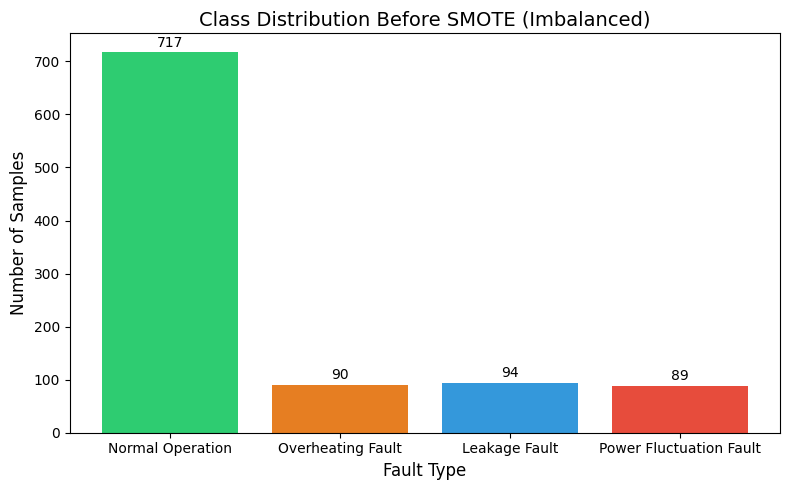


⚖️ STEP 4: APPLYING SMOTE BALANCING

Class distribution AFTER SMOTE:
   Normal Operation: 717 samples
   Overheating Fault: 717 samples
   Leakage Fault: 717 samples
   Power Fluctuation Fault: 717 samples


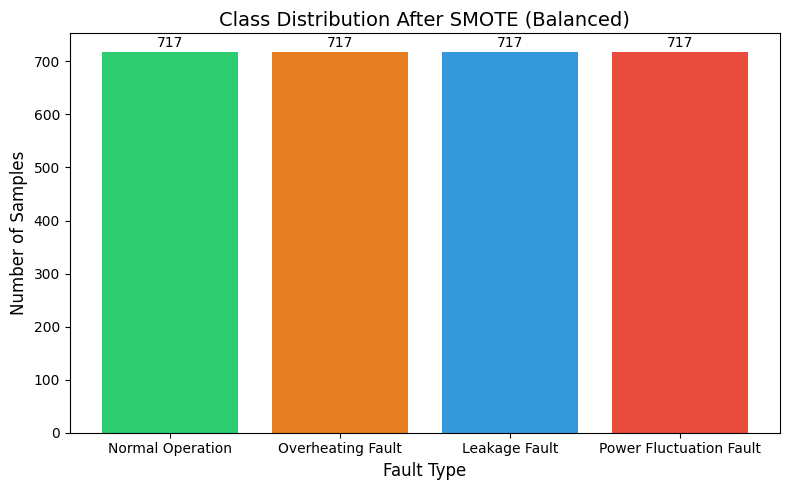


🤖 STEP 5: TRAINING RANDOM FOREST MODEL
Training set: 2294 samples
Test set: 574 samples

Training in progress...
✅ Training complete!

📊 STEP 6: CONFUSION MATRIX ANALYSIS


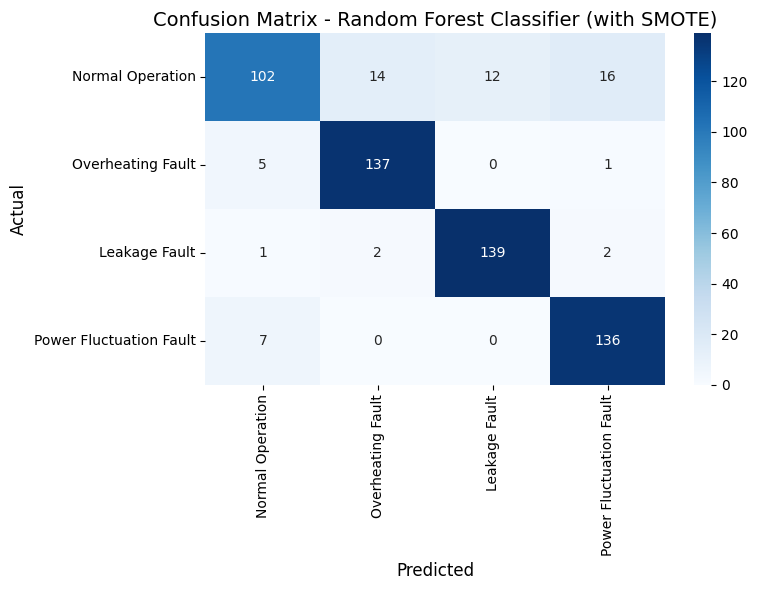


📖 Confusion Matrix Interpretation:
   ✅ Normal Operation correctly classified: 102 out of 144
   ✅ Overheating Fault correctly classified: 137 out of 143
   ✅ Leakage Fault correctly classified: 139 out of 144
   ✅ Power Fluctuation Fault correctly classified: 136 out of 143

📈 STEP 7: CLASSIFICATION REPORT

🎯 Overall Performance Metrics:
   Accuracy: 89.55%
   Precision (macro): 0.8951
   Recall (macro): 0.8957
   F1-Score (macro): 0.8921

📋 Per-Class Performance:
                         precision    recall  f1-score   support

       Normal Operation       0.89      0.71      0.79       144
      Overheating Fault       0.90      0.96      0.93       143
          Leakage Fault       0.92      0.97      0.94       144
Power Fluctuation Fault       0.88      0.95      0.91       143

               accuracy                           0.90       574
              macro avg       0.90      0.90      0.89       574
           weighted avg       0.90      0.90      0.89       574


🔝 STE

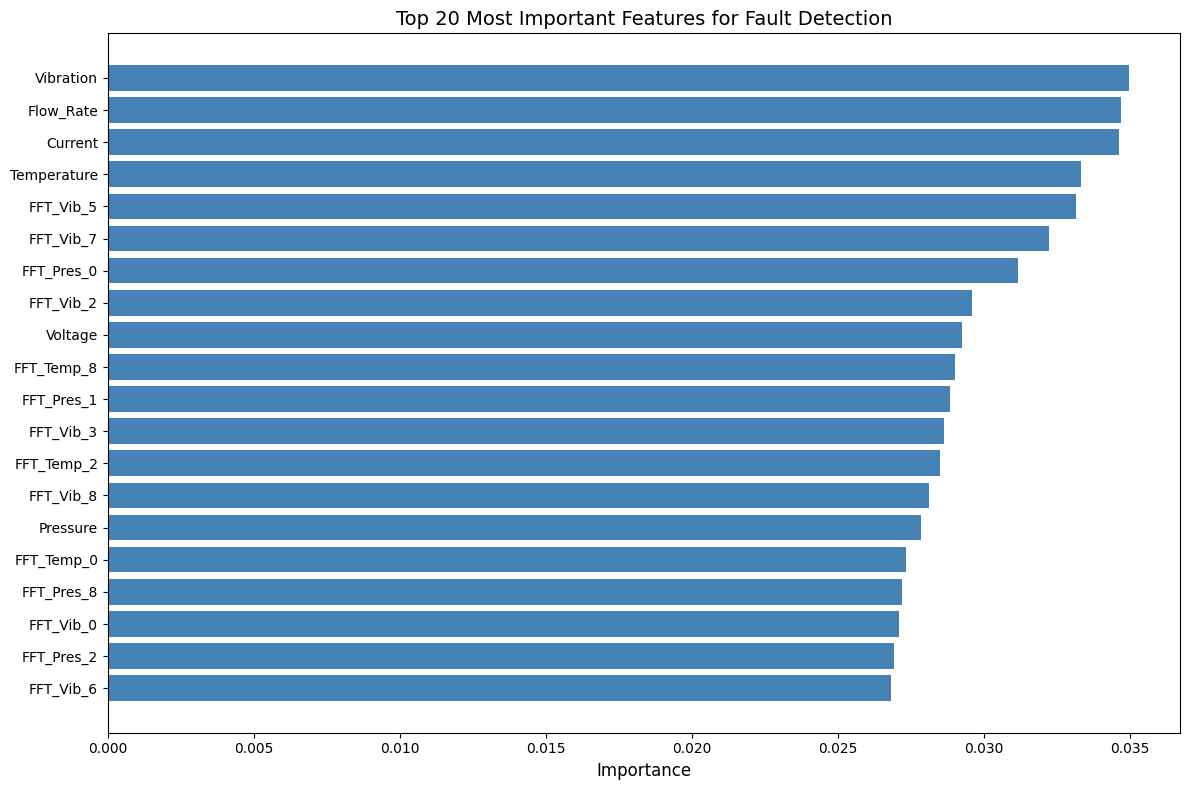


🔍 Top 10 Most Important Features for Fault Detection:
    1. Vibration                      📊 Raw   : 0.0350
    2. Flow_Rate                      📊 Raw   : 0.0347
    3. Current                        📊 Raw   : 0.0346
    4. Temperature                    📊 Raw   : 0.0333
    5. FFT_Vib_5                      🔊 FFT   : 0.0331
    6. FFT_Vib_7                      🔊 FFT   : 0.0322
    7. FFT_Pres_0                     🔊 FFT   : 0.0312
    8. FFT_Vib_2                      🔊 FFT   : 0.0296
    9. Voltage                        📊 Raw   : 0.0292
   10. FFT_Temp_8                     🔊 FFT   : 0.0290

📌 Key Finding: 5/10 top features are FFT features
   -> Frequency-domain analysis is crucial for fault detection!

📊 STEP 9: TRAINING DATA SIGNAL ANALYSIS


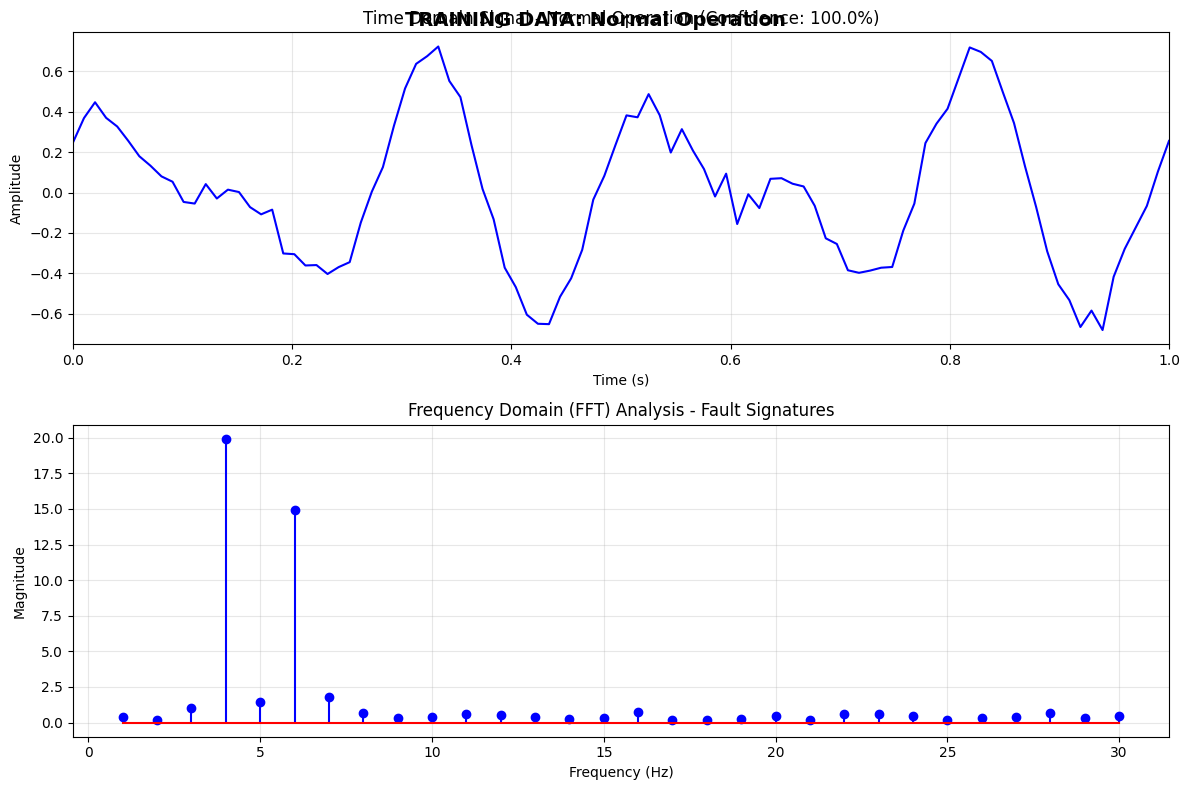

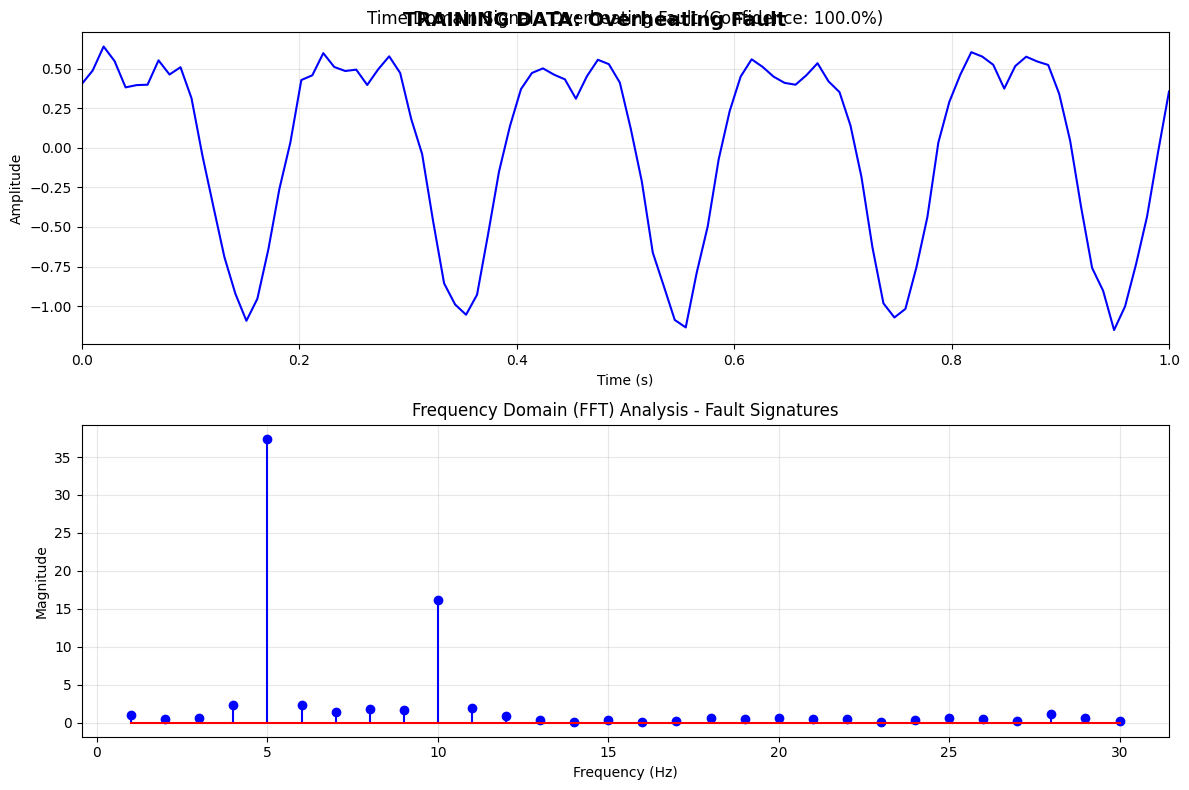

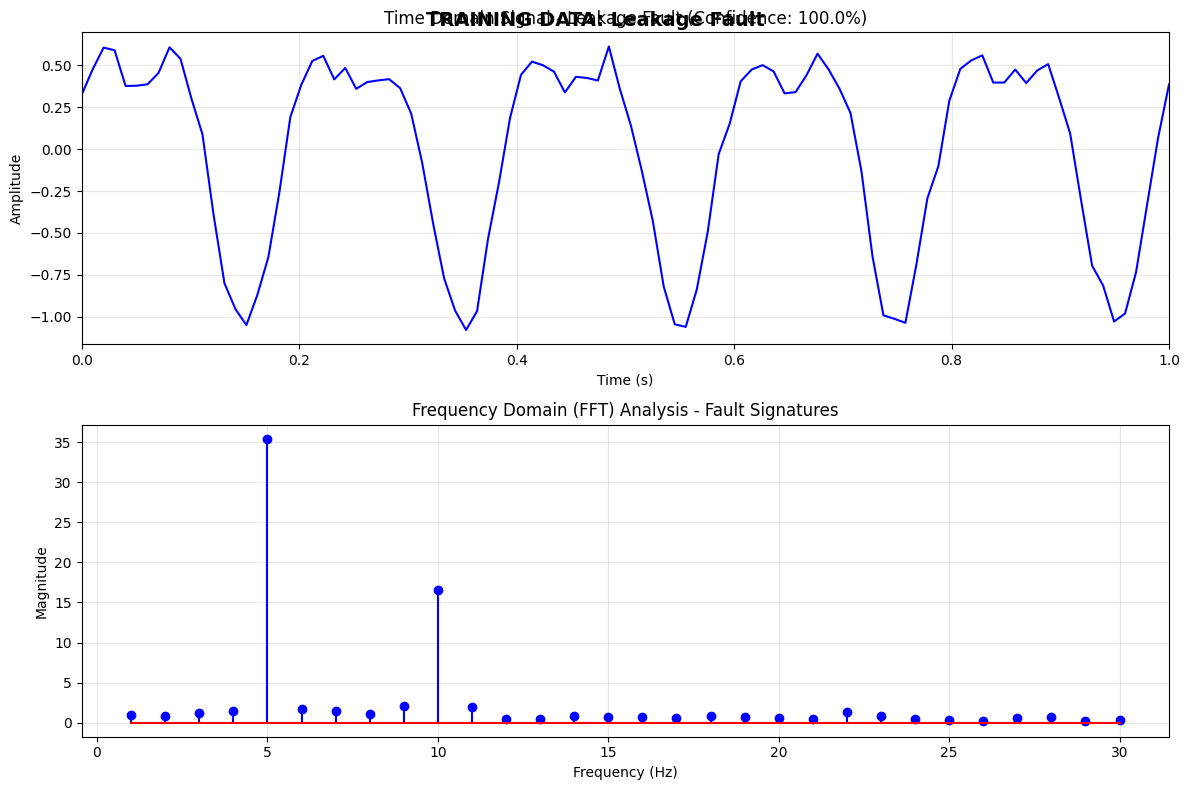

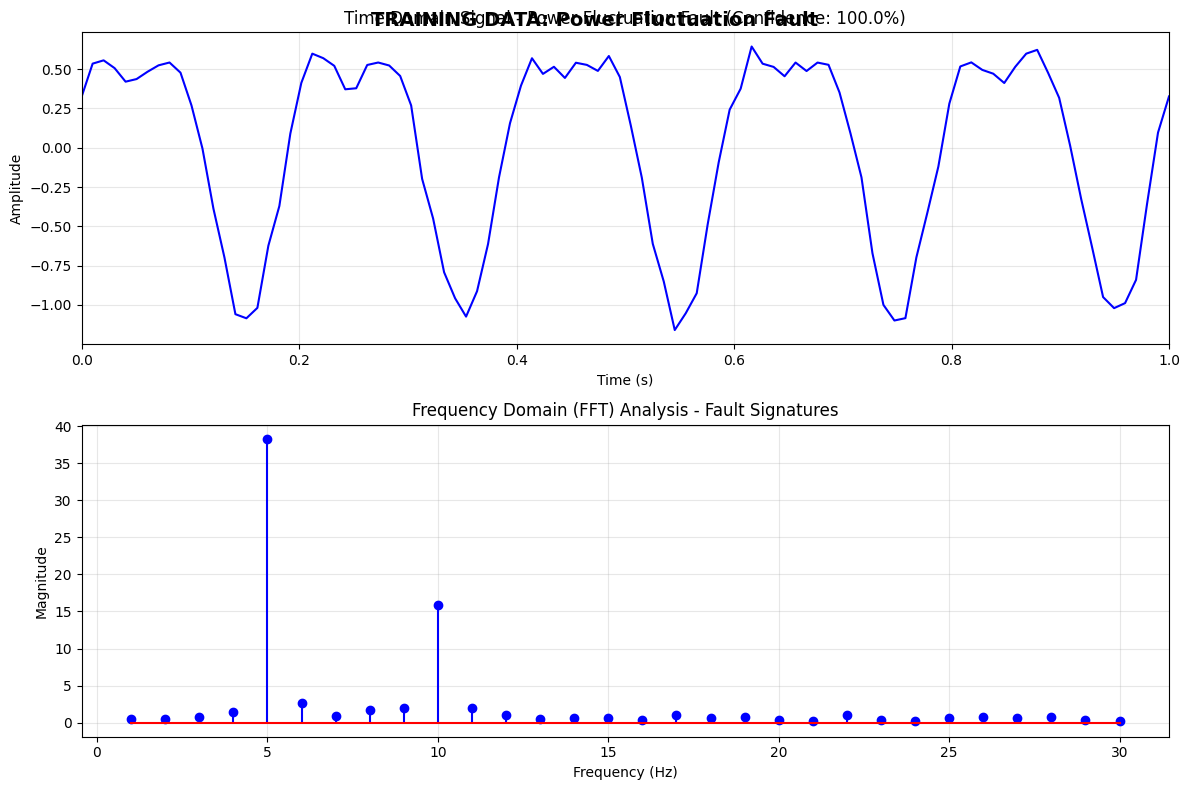


💾 STEP 10: SAVING MODEL
✅ Model saved successfully!

🔧 INDUSTRIAL FAULT DETECTION SYSTEM

🎯 Model Accuracy: 89.55%
📊 F1-Score: 0.8921

📋 MAIN MENU:
   [1] Manual Entry (with signal graphs)
   [2] CSV Batch Prediction
   [3] Test Scenarios
   [4] View Confusion Matrix & Report
   [5] 📥 ADD NEW DATA & RETRAIN MODEL (NEW!)
   [6] Exit


In [ ]:
# INDUSTRIAL FAULT DETECTION SYSTEM WITH LOADED DATA PREVIEW
# COMPLETE WORKING CODE WITH NEW DATA ADDING FEATURE

!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
import joblib
import io
import os

print("✅ All libraries loaded!")

# FAULT CATEGORIES

fault_names = {
    0: "Normal Operation",
    1: "Overheating Fault",
    2: "Leakage Fault",
    3: "Power Fluctuation Fault"
}

fault_names_display = {
    0: "✅ NORMAL OPERATION - No fault detected",
    1: "🔥 OVERHEATING FAULT - Check cooling system",
    2: "💧 LEAKAGE FAULT - Inspect pipes and seals",
    3: "⚡ POWER FLUCTUATION - Check voltage regulator"
}

fault_icons = {0: "🟢", 1: "🔥", 2: "💧", 3: "⚡"}

fault_risk = {
    0: "🟢 LOW - Continue normal operation",
    1: "🟠 MEDIUM - Schedule cooling system inspection",
    2: "🟡 MEDIUM-HIGH - Check for leaks immediately",
    3: "🔴 HIGH - Inspect power supply urgently"
}

fault_recommendations = {
    0: "Regular monitoring is sufficient. No action needed.",
    1: "Check cooling system, reduce load, inspect thermal sensors.",
    2: "Inspect pipes, valves, and seals for leaks. Check pump efficiency.",
    3: "Check voltage regulator, UPS system, and power quality."
}

# ============================================================
# NEW: FFT FEATURE GENERATION FROM RAW SIGNALS
# ============================================================
def generate_time_domain_signal_from_sensors(temp, vib, pres, flow, curr, volt, sample_rate=100):
    """Generate synthetic time domain signal from sensor parameters"""
    t = np.linspace(0, 1, sample_rate)

    if temp > 80:  # Overheating pattern
        signal = (temp / 100) * np.sin(2 * np.pi * 8 * t) + \
                 (vib / 10) * np.sin(2 * np.pi * 12 * t) + \
                 0.1 * np.sin(2 * np.pi * 20 * t)
    elif pres < 90:  # Leakage pattern
        signal = (temp / 100) * np.sin(2 * np.pi * 4 * t) + \
                 (pres / 200) * np.cos(2 * np.pi * 6 * t) + \
                 0.05 * np.random.randn(len(t))
    elif volt < 210 or volt > 230:  # Power fluctuation pattern
        signal = (temp / 100) * np.sin(2 * np.pi * 5 * t) + \
                 0.3 * np.sin(2 * np.pi * 25 * t) + \
                 0.15 * np.sin(2 * np.pi * 50 * t)
    else:  # Normal operation
        signal = (temp / 100) * np.sin(2 * np.pi * 5 * t) + \
                 (vib / 10) * np.cos(2 * np.pi * 10 * t) + \
                 0.02 * np.random.randn(len(t))

    noise = np.random.normal(0, 0.03, len(signal))
    signal = signal + noise
    return t, signal

def generate_fft_features_from_signal(signal, sample_rate=100, n_fft_bins=20):
    """Generate FFT features from a time-domain signal"""
    fft_vals = np.fft.fft(signal)
    fft_magnitude = np.abs(fft_vals[:len(signal)//2])
    fft_freq = np.fft.fftfreq(len(signal), 1/sample_rate)[:len(signal)//2]

    # Create FFT features (bin averages)
    bin_size = max(1, len(fft_magnitude) // n_fft_bins)
    fft_features = []
    for i in range(n_fft_bins):
        start = i * bin_size
        end = min(start + bin_size, len(fft_magnitude))
        if start < len(fft_magnitude):
            fft_features.append(np.mean(fft_magnitude[start:end]))
        else:
            fft_features.append(0)

    return fft_features, fft_freq, fft_magnitude

def create_complete_fft_features(temp, vib, pres, flow, curr, volt):
    """Create complete FFT features from sensor readings"""
    t, signal = generate_time_domain_signal_from_sensors(temp, vib, pres, flow, curr, volt)
    fft_features, fft_freq, fft_magnitude = generate_fft_features_from_signal(signal)
    return fft_features, t, signal, fft_freq, fft_magnitude

def plot_new_data_signal(signal, fft_freq, fft_magnitude, fault_name, sample_num=1):
    """Plot time domain and FFT for new data"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    t = np.linspace(0, 1, len(signal))

    # Time Domain
    axes[0].plot(t, signal, 'b-', linewidth=1.5)
    axes[0].set_xlabel('Time (s)', fontsize=12)
    axes[0].set_ylabel('Amplitude', fontsize=12)
    axes[0].set_title(f'Time Domain Signal - New Data Sample #{sample_num}', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1)

    # FFT
    axes[1].stem(fft_freq[:50], fft_magnitude[:50], linefmt='b-', markerfmt='bo', basefmt='r-')
    axes[1].set_xlabel('Frequency (Hz)', fontsize=12)
    axes[1].set_ylabel('Magnitude', fontsize=12)
    axes[1].set_title(f'FFT Analysis - {fault_name}', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# ============================================================
# SIGNAL VISUALIZATION FUNCTIONS
# ============================================================
def generate_time_domain_signal(values, sample_rate=100):
    """Generate a synthetic time domain signal from feature values"""
    t = np.linspace(0, 1, sample_rate)
    if values[0] > 80:
        signal = (values[0] / 100) * np.sin(2 * np.pi * 8 * t) + \
                 (values[1] / 10) * np.sin(2 * np.pi * 12 * t)
    elif values[2] < 90:
        signal = (values[0] / 100) * np.sin(2 * np.pi * 4 * t) + \
                 (values[2] / 200) * np.cos(2 * np.pi * 6 * t)
    elif values[5] < 210 or values[5] > 230:
        signal = (values[0] / 100) * np.sin(2 * np.pi * 5 * t) + \
                 0.3 * np.sin(2 * np.pi * 25 * t)
    else:
        signal = (values[0] / 100) * np.sin(2 * np.pi * 5 * t) + \
                 (values[1] / 10) * np.cos(2 * np.pi * 10 * t)
    noise = np.random.normal(0, 0.05, len(signal))
    signal = signal + noise
    return t, signal

def plot_combined_signals(parameters, fault_name, confidence):
    """Plot both time domain and FFT together"""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    values = list(parameters.values())[:6]
    t, signal = generate_time_domain_signal(values)

    axes[0].plot(t, signal, 'b-', linewidth=1.5)
    axes[0].set_xlabel('Time (s)', fontsize=10)
    axes[0].set_ylabel('Amplitude', fontsize=10)
    axes[0].set_title(f'Time Domain Signal - {fault_name} (Confidence: {confidence:.1f}%)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1)

    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(len(signal), 1/100)
    positive_idx = fft_freq > 0
    axes[1].stem(fft_freq[positive_idx][:30], np.abs(fft_vals[positive_idx][:30]),
                 linefmt='b-', markerfmt='bo', basefmt='r-')
    axes[1].set_xlabel('Frequency (Hz)', fontsize=10)
    axes[1].set_ylabel('Magnitude', fontsize=10)
    axes[1].set_title('Frequency Domain (FFT) Analysis - Fault Signatures', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

# ============================================================
# FUNCTION 1: LOADED DATA PREVIEW
# ============================================================
def preview_loaded_data(df, filename):
    """Display comprehensive preview of loaded data"""
    print("\n" + "="*70)
    print("📊 LOADED DATA PREVIEW")
    print("="*70)
    print(f"\n📁 File Name: {filename}")
    print(f"📏 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    print("\n" + "─"*70)
    print("📋 FIRST 5 ROWS (Preview):")
    print("─"*70)
    print(df.head())

    print("\n" + "─"*70)
    print("📋 LAST 5 ROWS (Preview):")
    print("─"*70)
    print(df.tail())

    print("\n" + "─"*70)
    print("📋 COLUMN INFORMATION:")
    print("─"*70)
    col_info = pd.DataFrame({
        'Column Name': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.count().values,
        'Null Count': df.isnull().sum().values,
        'Unique Values': df.nunique().values
    })
    print(col_info.to_string(index=False))

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        print("\n" + "─"*70)
        print("📊 STATISTICAL SUMMARY (Numeric Columns):")
        print("─"*70)
        print(df[numeric_cols].describe().round(2))

    if 'Fault_Type' in df.columns:
        print("\n" + "─"*70)
        print("📊 FAULT TYPE DISTRIBUTION:")
        print("─"*70)
        fault_counts = df['Fault_Type'].value_counts().sort_index()
        for ft, count in fault_counts.items():
            fault_name = fault_names.get(ft, f"Unknown ({ft})")
            percentage = (count / len(df)) * 100
            bar = "█" * int(percentage / 2)
            print(f"   {ft} -> {fault_name:25s}: {count:4d} samples ({percentage:5.1f}%) {bar}")

    fft_cols = [col for col in df.columns if col.startswith('FFT_')]
    raw_cols = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage']
    existing_raw = [col for col in raw_cols if col in df.columns]

    print("\n" + "─"*70)
    print("🔍 FEATURE COLUMNS ANALYSIS:")
    print("─"*70)
    print(f"   ✅ Raw Sensor Features ({len(existing_raw)}): {existing_raw}")
    print(f"   🔊 FFT Features ({len(fft_cols)}): {fft_cols[:5]}{'...' if len(fft_cols) > 5 else ''}")

    return fft_cols, existing_raw

# ============================================================
# FUNCTION 2: VISUALIZE DATA DISTRIBUTIONS
# ============================================================
def plot_data_distributions(df, existing_raw):
    """Plot histograms of raw sensor features"""
    print("\n" + "="*70)
    print("📊 PLOTTING DATA DISTRIBUTIONS")
    print("="*70)

    plot_cols = [col for col in existing_raw if col in df.columns]
    if plot_cols:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.flatten()
        for i, col in enumerate(plot_cols):
            axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
            axes[i].set_xlabel(col, fontsize=10)
            axes[i].set_ylabel('Frequency', fontsize=10)
            axes[i].set_title(f'Distribution of {col}', fontsize=12)
            axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
            axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
            axes[i].legend(fontsize=8)
        for i in range(len(plot_cols), len(axes)):
            axes[i].set_visible(False)
        plt.suptitle('Distribution of Raw Sensor Features', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No raw sensor columns found for distribution plot")

# ============================================================
# FUNCTION 3: CORRELATION HEATMAP
# ============================================================
def plot_correlation_heatmap(df, existing_raw, fft_cols):
    """Plot correlation heatmap for raw and FFT features"""
    print("\n" + "="*70)
    print("📊 PLOTTING CORRELATION HEATMAP")
    print("="*70)

    selected_cols = existing_raw.copy()
    if fft_cols:
        selected_cols.extend(fft_cols[:10])
    selected_cols = [col for col in selected_cols if col in df.columns]

    if len(selected_cols) > 1:
        plt.figure(figsize=(14, 12))
        correlation_matrix = df[selected_cols].corr()
        mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
        sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
                    cmap='RdBu_r', center=0, square=True,
                    linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Not enough columns for correlation heatmap")

# ============================================================
# NEW FUNCTION: ADD NEW DATA
# ============================================================
def add_new_data_and_retrain():
    """Add new data with automatic FFT generation and retrain model"""
    global df, X, y, X_scaled, rf_model, scaler, mean_fft_values, feature_cols, fft_cols
    global accuracy, f1_macro, precision_macro, recall_macro, cm, y_pred, y_test

    print("\n" + "="*70)
    print("📥 ADD NEW DATA TO TRAINED SYSTEM")
    print("="*70)
    print("\nThis feature adds new sensor readings, generates FFT features automatically,")
    print("shows time-domain and FFT graphs, and retrains the model.")

    new_samples = []

    print("\n📊 How would you like to add new data?")
    print("   [1] Manual Entry (single sample)")
    print("   [2] CSV Upload (multiple samples)")

    method = input("\n👉 Enter choice (1-2): ").strip()

    if method == '1':
        print("\n" + "─"*70)
        print("✏️ MANUAL DATA ENTRY")
        print("─"*70)

        try:
            temp = float(input("   Temperature (°C): "))
            vib = float(input("   Vibration: "))
            pres = float(input("   Pressure: "))
            flow = float(input("   Flow Rate: "))
            curr = float(input("   Current (A): "))
            volt = float(input("   Voltage (V): "))

            print("\n📊 Select the TRUE FAULT TYPE:")
            print("   [0] Normal Operation")
            print("   [1] Overheating Fault")
            print("   [2] Leakage Fault")
            print("   [3] Power Fluctuation Fault")
            fault_type = int(input("\n👉 Enter fault type (0-3): "))

            # Generate FFT features
            fft_features, t, signal, fft_freq, fft_magnitude = create_complete_fft_features(temp, vib, pres, flow, curr, volt)

            # Show signal analysis for new data
            print("\n📊 NEW DATA SIGNAL ANALYSIS:")
            fig = plot_new_data_signal(signal, fft_freq, fft_magnitude, fault_names[fault_type], 1)
            plt.suptitle('NEW DATA: Time Domain and FFT Analysis', fontsize=14, fontweight='bold')
            plt.show()

            # Create sample
            sample = {
                'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
                'Flow_Rate': flow, 'Current': curr, 'Voltage': volt, 'Fault_Type': fault_type
            }
            for i, ff_val in enumerate(fft_features[:len(fft_cols)]):
                sample[f'FFT_{i+1}'] = ff_val
            new_samples.append(sample)
            print(f"\n✅ New sample prepared!")

        except ValueError:
            print("❌ Invalid input!")
            return

    elif method == '2':
        print("\n📁 Upload CSV file with new data")
        print("\n📋 CSV FORMAT REQUIRED:")
        print("   Temperature,Vibration,Pressure,Flow_Rate,Current,Voltage,Fault_Type")

        uploaded = files.upload()
        if not uploaded:
            print("❌ No file uploaded")
            return

        filename = list(uploaded.keys())[0]
        new_df = pd.read_csv(filename)
        print(f"\n✅ Loaded {len(new_df)} samples")

        for idx, row in new_df.iterrows():
            temp = row['Temperature']
            vib = row['Vibration']
            pres = row['Pressure']
            flow = row['Flow_Rate']
            curr = row['Current']
            volt = row['Voltage']
            fault_type = row.get('Fault_Type', 0)

            fft_features, t, signal, fft_freq, fft_magnitude = create_complete_fft_features(temp, vib, pres, flow, curr, volt)

            sample = {
                'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
                'Flow_Rate': flow, 'Current': curr, 'Voltage': volt, 'Fault_Type': fault_type
            }
            for i, ff_val in enumerate(fft_features[:len(fft_cols)]):
                sample[f'FFT_{i+1}'] = ff_val
            new_samples.append(sample)

            # Show first 3 samples
            if idx < 3:
                print(f"\n📊 Sample #{idx+1} Signal Analysis:")
                fig = plot_new_data_signal(signal, fft_freq, fft_magnitude, fault_names[fault_type], idx+1)
                plt.suptitle(f'NEW DATA SAMPLE #{idx+1}', fontsize=14, fontweight='bold')
                plt.show()

        print(f"\n✅ Processed {len(new_samples)} new samples!")

    if not new_samples:
        print("❌ No new samples to add")
        return

    new_df = pd.DataFrame(new_samples)

    # Ensure all FFT columns exist
    for i, col in enumerate(fft_cols):
        if col not in new_df.columns:
            new_df[col] = 0

    print("\n" + "─"*70)
    print("📊 NEW DATA SUMMARY:")
    print("─"*70)
    print(new_df[['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage', 'Fault_Type']].head())

    confirm = input(f"\n⚠️ Add {len(new_samples)} new sample(s) and RETRAIN the model? (yes/no): ").lower()
    if confirm != 'yes':
        print("❌ Operation cancelled")
        return

    # Merge and retrain
    print("\n🔄 Merging new data with existing dataset...")

    # Get original data columns
    original_data = pd.DataFrame(X.copy())
    original_data['Fault_Type'] = y.copy()

    # Ensure column alignment
    for col in fft_cols:
        if col not in original_data.columns:
            original_data[col] = 0

    combined_df = pd.concat([original_data, new_df], ignore_index=True)
    print(f"✅ Combined dataset: {combined_df.shape[0]} samples")

    # Retrain
    print("\n🔄 RETRAINING MODEL WITH NEW DATA...")

    feature_cols_new = [col for col in combined_df.columns if col != 'Fault_Type']
    X_new = combined_df[feature_cols_new].copy()
    y_new = combined_df['Fault_Type'].copy()

    X_new = X_new.fillna(X_new.mean())
    X_new = X_new.replace([np.inf, -np.inf], np.nan)
    X_new = X_new.fillna(X_new.mean())

    scaler_new = StandardScaler()
    X_scaled_new = scaler_new.fit_transform(X_new)

    smote = SMOTE(random_state=42)
    X_balanced_new, y_balanced_new = smote.fit_resample(X_scaled_new, y_new)

    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
        X_balanced_new, y_balanced_new, test_size=0.2, random_state=42, stratify=y_balanced_new
    )

    rf_model_new = RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=10,
        min_samples_leaf=4, random_state=42, n_jobs=-1
    )
    rf_model_new.fit(X_train_new, y_train_new)

    y_pred_new = rf_model_new.predict(X_test_new)
    accuracy_new = accuracy_score(y_test_new, y_pred_new)
    f1_macro_new = f1_score(y_test_new, y_pred_new, average='macro')

    # Update global variables
    df = combined_df
    X = X_new
    y = y_new
    X_scaled = X_scaled_new
    rf_model = rf_model_new
    scaler = scaler_new
    feature_cols = feature_cols_new
    accuracy = accuracy_new
    f1_macro = f1_macro_new
    precision_macro = precision_score(y_test_new, y_pred_new, average='macro')
    recall_macro = recall_score(y_test_new, y_pred_new, average='macro')
    cm = confusion_matrix(y_test_new, y_pred_new)
    y_pred = y_pred_new
    y_test = y_test_new

    # Update mean FFT values
    mean_fft_values = {}
    for col in [c for c in feature_cols if c.startswith('FFT_')]:
        mean_fft_values[col] = X[col].mean()

    print("\n" + "="*70)
    print("✅ MODEL RETRAINING COMPLETE!")
    print("="*70)
    print(f"\n📊 UPDATED MODEL PERFORMANCE:")
    print(f"   Accuracy: {accuracy*100:.2f}%")
    print(f"   F1-Score: {f1_macro:.4f}")
    print(f"   Precision: {precision_macro:.4f}")
    print(f"   Recall: {recall_macro:.4f}")

    # Show updated confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'],
                yticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'])
    plt.title('UPDATED Confusion Matrix (After Adding New Data)', fontsize=14)
    plt.show()

    # Save updated model
    joblib.dump(rf_model, 'fault_detection_model_updated.pkl')
    joblib.dump(scaler, 'scaler_updated.pkl')
    joblib.dump(mean_fft_values, 'mean_fft_values_updated.pkl')
    joblib.dump(feature_cols, 'feature_cols_updated.pkl')
    print("\n💾 Updated model saved as 'fault_detection_model_updated.pkl'")

    return True

# ============================================================
# PREDICTION FUNCTIONS
# ============================================================

def predict_with_signals(temp, vib, pres, flow, curr, volt):
    """Predict fault and display time domain + FFT graphs"""
    params = {
        'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
        'Flow_Rate': flow, 'Current': curr, 'Voltage': volt
    }

    input_dict = {
        'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
        'Flow_Rate': flow, 'Current': curr, 'Voltage': volt
    }

    for col in fft_cols:
        input_dict[col] = mean_fft_values.get(col, 0)

    input_df = pd.DataFrame([input_dict])
    input_df = input_df[feature_cols]
    input_scaled = scaler.transform(input_df)

    prediction = rf_model.predict(input_scaled)[0]
    probabilities = rf_model.predict_proba(input_scaled)[0]
    confidence = probabilities[prediction] * 100

    print("\n" + "="*70)
    print("🔍 PREDICTION RESULT")
    print("="*70)
    print(f"\n📊 INPUT VALUES:")
    print(f"   Temperature: {temp}°C", "⚠️ HIGH" if temp > 80 else "✅ NORMAL")
    print(f"   Vibration: {vib}", "⚠️ HIGH" if vib > 3.5 else "✅ NORMAL")
    print(f"   Pressure: {pres}", "⚠️ LOW" if pres < 90 else "⚠️ HIGH" if pres > 105 else "✅ NORMAL")
    print(f"   Flow Rate: {flow}", "⚠️ LOW" if flow < 8 else "✅ NORMAL")
    print(f"   Current: {curr} A", "⚠️ HIGH" if curr > 18 else "✅ NORMAL")
    print(f"   Voltage: {volt} V", "⚠️ LOW" if volt < 210 else "⚠️ HIGH" if volt > 230 else "✅ NORMAL")

    print(f"\n{fault_icons.get(prediction, '?')} {fault_names_display.get(prediction, f'UNKNOWN FAULT ({prediction})')}")
    print(f"📈 Confidence: {confidence:.1f}%")
    print(f"🛡️ Risk Level: {fault_risk.get(prediction, '? UNKNOWN')}")
    print(f"💡 Recommendation: {fault_recommendations.get(prediction, 'Please consult maintenance manual.')}")

    print("\n📉 Probability Distribution:")
    for i, prob in enumerate(probabilities[:4]):
        bar = "█" * int(prob * 40)
        class_name = fault_names.get(i, f"Class {i}")
        print(f"   {class_name:20s}: {prob*100:5.1f}% {bar}")

    fig = plot_combined_signals(params, fault_names.get(prediction, "Unknown Fault"), confidence)
    plt.suptitle(f'PREDICTED: {fault_names.get(prediction, "Unknown Fault")} (Confidence: {confidence:.1f}%)',
                 fontsize=14, fontweight='bold')
    plt.show()
    return prediction, probabilities

def batch_prediction():
    print("\n" + "="*70)
    print("📁 BATCH PREDICTION FROM CSV")
    print("="*70)
    print("\n📋 CSV FORMAT (6 columns):")
    print("   Temperature,Vibration,Pressure,Flow_Rate,Current,Voltage")

    print("\n📁 Upload your CSV file...")
    uploaded = files.upload()
    if not uploaded:
        print("❌ No file uploaded")
        return

    filename = list(uploaded.keys())[0]
    new_data = pd.read_csv(filename)
    print(f"\n✅ Loaded {len(new_data)} samples")

    results = []
    for i in range(len(new_data)):
        temp = new_data['Temperature'].iloc[i]
        vib = new_data['Vibration'].iloc[i]
        pres = new_data['Pressure'].iloc[i]
        flow = new_data['Flow_Rate'].iloc[i]
        curr = new_data['Current'].iloc[i]
        volt = new_data['Voltage'].iloc[i]

        print(f"\n{'='*60}")
        print(f"📊 Sample #{i+1}")
        print(f"{'='*60}")
        pred, probs = predict_with_signals(temp, vib, pres, flow, curr, volt)
        results.append({'ID': i+1, 'Temperature': temp, 'Vibration': vib,
                       'Pressure': pres, 'Prediction': fault_names.get(pred, "Unknown"),
                       'Confidence': f"{probs[pred]*100:.1f}%"})

    print("\n" + "="*70)
    print("📊 SUMMARY RESULTS")
    print("="*70)
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    save = input("\n💾 Save results to CSV? (yes/no): ").lower()
    if save == 'yes':
        results_df.to_csv('batch_results.csv', index=False)
        files.download('batch_results.csv')
        print("✅ Results saved!")

def manual_prediction():
    print("\n" + "="*70)
    print("✏️ MANUAL PREDICTION MODE")
    print("="*70)
    print("\n📋 NORMAL OPERATING RANGES:")
    print("   Temperature: 70-80°C | Vibration: 2.5-3.5")
    print("   Pressure: 90-105 | Flow Rate: 8-12")
    print("   Current: 12-18 A | Voltage: 210-230 V")

    count = 0
    while True:
        count += 1
        print(f"\n📊 MACHINE #{count}")
        print("-"*40)
        try:
            temp = float(input("   Temperature (°C): "))
            vib = float(input("   Vibration: "))
            pres = float(input("   Pressure: "))
            flow = float(input("   Flow Rate: "))
            curr = float(input("   Current (A): "))
            volt = float(input("   Voltage (V): "))
            predict_with_signals(temp, vib, pres, flow, curr, volt)
            another = input("\n🔁 Predict another machine? (yes/no): ").lower()
            if another != 'yes':
                break
        except ValueError:
            print("❌ Invalid input! Please enter numeric values.")

def test_scenarios():
    print("\n" + "="*70)
    print("🧪 TEST SCENARIOS")
    print("="*70)
    test_cases = [
        {"name": "NORMAL OPERATION", "temp": 75, "vib": 3.0, "pres": 100, "flow": 10, "curr": 15, "volt": 220},
        {"name": "OVERHEATING FAULT", "temp": 85, "vib": 4.0, "pres": 102, "flow": 11, "curr": 24, "volt": 220},
        {"name": "LEAKAGE FAULT", "temp": 74, "vib": 3.2, "pres": 82, "flow": 6.5, "curr": 16, "volt": 218},
        {"name": "POWER FLUCTUATION", "temp": 76, "vib": 3.3, "pres": 100, "flow": 10, "curr": 14, "volt": 205},
    ]
    for case in test_cases:
        print(f"\n{'='*60}")
        print(f"Testing: {case['name']}")
        print(f"{'='*60}")
        predict_with_signals(case['temp'], case['vib'], case['pres'],
                            case['flow'], case['curr'], case['volt'])

# ============================================================
# COMPLETE MAIN MENU WITH NEW DATA FEATURE
# ============================================================
def main_menu():
    while True:
        print("\n" + "="*70)
        print("🔧 INDUSTRIAL FAULT DETECTION SYSTEM")
        print("="*70)
        print(f"\n🎯 Model Accuracy: {accuracy*100:.2f}%")
        print(f"📊 F1-Score: {f1_macro:.4f}")
        print("\n📋 MAIN MENU:")
        print("   [1] Manual Entry (with signal graphs)")
        print("   [2] CSV Batch Prediction")
        print("   [3] Test Scenarios")
        print("   [4] View Confusion Matrix & Report")
        print("   [5] 📥 ADD NEW DATA & RETRAIN MODEL (NEW!)")
        print("   [6] Exit")

        choice = input("\n👉 Enter choice (1-6): ").strip()

        if choice == '1':
            manual_prediction()
        elif choice == '2':
            batch_prediction()
        elif choice == '3':
            test_scenarios()
        elif choice == '4':
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'],
                        yticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'])
            plt.title('Confusion Matrix', fontsize=14)
            plt.show()
            print(f"\n📊 Performance Summary:")
            print(f"   Accuracy: {accuracy*100:.2f}%")
            print(f"   F1-Score: {f1_macro:.4f}")
            print(f"   Precision: {precision_macro:.4f}")
            print(f"   Recall: {recall_macro:.4f}")
            print("\n📋 Classification Report:")
            print(classification_report(y_test, y_pred,
                                       target_names=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation']))
            input("\nPress Enter to continue...")
        elif choice == '5':
            add_new_data_and_retrain()
        elif choice == '6':
            print("\n" + "="*70)
            print("✅ Thank you for using the Fault Detection System!")
            print("👋 Goodbye!")
            print("="*70)
            break
        else:
            print("❌ Invalid choice. Please enter 1-6.")

# ============================================================
# MAIN EXECUTION
# ============================================================

print("\n" + "="*70)
print("📁 STEP 1: UPLOAD YOUR TRAINING DATASET")
print("="*70)
print("Please upload your CSV file (Industrial_fault_detection (1).csv)")

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# DISPLAY LOADED DATA PREVIEW
fft_cols, existing_raw = preview_loaded_data(df, filename)

# PLOT DATA DISTRIBUTIONS
plot_data_distributions(df, existing_raw)

# PLOT CORRELATION HEATMAP
plot_correlation_heatmap(df, existing_raw, fft_cols)

# DATA PREPROCESSING
print("\n" + "="*70)
print("🔧 STEP 2: DATA PREPROCESSING")
print("="*70)

feature_cols = [col for col in df.columns if col != 'Fault_Type']
X = df[feature_cols].copy()
y = df['Fault_Type'].copy()

if 'fft_cols' not in dir():
    fft_cols = [col for col in feature_cols if col.startswith('FFT_')]
raw_cols = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage']
existing_raw = [col for col in raw_cols if col in df.columns]

print(f"Raw sensor features: {len(existing_raw)}")
print(f"FFT features: {len(fft_cols)}")
print(f"Total features: {len(feature_cols)}")

if fft_cols:
    zero_fft_rows = (X[fft_cols] == 0).all(axis=1).sum()
    if zero_fft_rows > 0:
        print(f"\n⚠️ Found {zero_fft_rows} rows with all zero FFT features")
        mask = ~(X[fft_cols] == 0).all(axis=1)
        X = X[mask]
        y = y[mask]
        print(f"✅ Removed corrupt rows. New shape: {X.shape}")

X = X.fillna(X.mean())
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

if fft_cols:
    mean_fft_values = {}
    for col in fft_cols:
        mean_fft_values[col] = X[col].mean()
else:
    mean_fft_values = {}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Preprocessing complete! Final shape: {X_scaled.shape}")

# CLASS DISTRIBUTION (BEFORE SMOTE)
print("\n" + "="*70)
print("📊 STEP 3: CLASS DISTRIBUTION ANALYSIS")
print("="*70)

fault_counts = y.value_counts().sort_index()
print("\nOriginal class distribution:")
for ft, count in fault_counts.items():
    print(f"   {fault_names.get(ft, f'Unknown ({ft})')}: {count} samples ({count/len(y)*100:.1f}%)")

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e67e22', '#3498db', '#e74c3c']
bars = plt.bar(fault_counts.index, fault_counts.values, color=colors[:len(fault_counts)])
plt.xlabel('Fault Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution Before SMOTE (Imbalanced)', fontsize=14)
plt.xticks(sorted(fault_counts.index), [fault_names.get(ft, ft) for ft in sorted(fault_counts.index)])
for bar, count in zip(bars, fault_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{count}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# APPLY SMOTE
print("\n" + "="*70)
print("⚖️ STEP 4: APPLYING SMOTE BALANCING")
print("="*70)

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

balanced_counts = pd.Series(y_balanced).value_counts().sort_index()
print("\nClass distribution AFTER SMOTE:")
for ft, count in balanced_counts.items():
    print(f"   {fault_names.get(ft, f'Unknown ({ft})')}: {count} samples")

plt.figure(figsize=(8, 5))
bars = plt.bar(balanced_counts.index, balanced_counts.values, color=colors[:len(balanced_counts)])
plt.xlabel('Fault Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution After SMOTE (Balanced)', fontsize=14)
plt.xticks(sorted(balanced_counts.index), [fault_names.get(ft, ft) for ft in sorted(balanced_counts.index)])
for bar, count in zip(bars, balanced_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{count}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# TRAIN-TEST SPLIT
print("\n" + "="*70)
print("🤖 STEP 5: TRAINING RANDOM FOREST MODEL")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=4, random_state=42, n_jobs=-1
)

print("\nTraining in progress...")
rf_model.fit(X_train, y_train)
print("✅ Training complete!")

# CONFUSION MATRIX
print("\n" + "="*70)
print("📊 STEP 6: CONFUSION MATRIX ANALYSIS")
print("="*70)

y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[fault_names.get(i, i) for i in range(len(cm))],
            yticklabels=[fault_names.get(i, i) for i in range(len(cm))])
plt.title('Confusion Matrix - Random Forest Classifier (with SMOTE)', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📖 Confusion Matrix Interpretation:")
for i in range(len(cm)):
    print(f"   ✅ {fault_names.get(i, f'Class {i}')} correctly classified: {cm[i][i]} out of {cm[i].sum()}")

# CLASSIFICATION REPORT
print("\n" + "="*70)
print("📈 STEP 7: CLASSIFICATION REPORT")
print("="*70)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')

print(f"\n🎯 Overall Performance Metrics:")
print(f"   Accuracy: {accuracy*100:.2f}%")
print(f"   Precision (macro): {precision_macro:.4f}")
print(f"   Recall (macro): {recall_macro:.4f}")
print(f"   F1-Score (macro): {f1_macro:.4f}")

print("\n📋 Per-Class Performance:")
print(classification_report(y_test, y_pred,
                           target_names=[fault_names.get(i, f'Class {i}') for i in range(len(set(y)))]))

# FEATURE IMPORTANCE
print("\n" + "="*70)
print("🔝 STEP 8: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_cols))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue')
plt.yticks(range(top_n), [feature_cols[i] for i in indices[:top_n]][::-1])
plt.xlabel('Importance', fontsize=12)
plt.title(f'Top {top_n} Most Important Features for Fault Detection', fontsize=14)
plt.tight_layout()
plt.show()

print("\n🔍 Top 10 Most Important Features for Fault Detection:")
for i in range(min(10, len(feature_cols))):
    fft_mark = "🔊 FFT" if feature_cols[indices[i]].startswith('FFT_') else "📊 Raw"
    print(f"   {i+1:2d}. {feature_cols[indices[i]]:30s} {fft_mark:8s}: {importances[indices[i]]:.4f}")

fft_count = sum(1 for i in range(min(10, len(feature_cols))) if feature_cols[indices[i]].startswith('FFT_'))
print(f"\n📌 Key Finding: {fft_count}/10 top features are FFT features")
print("   -> Frequency-domain analysis is crucial for fault detection!")

# TRAINING DATA SIGNAL VISUALIZATION
print("\n" + "="*70)
print("📊 STEP 9: TRAINING DATA SIGNAL ANALYSIS")
print("="*70)

for fault_type in sorted(df['Fault_Type'].unique()):
    samples = df[df['Fault_Type'] == fault_type]
    if len(samples) > 0:
        sample = samples.iloc[0]
        params = {}
        for col in ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage']:
            if col in df.columns:
                params[col] = sample[col]
            else:
                params[col] = 0
        if len(params) > 0:
            fig = plot_combined_signals(params, fault_names.get(fault_type, f"Fault {fault_type}"), 100)
            plt.suptitle(f'TRAINING DATA: {fault_names.get(fault_type, f"Fault {fault_type}")}', fontsize=14, fontweight='bold')
            plt.show()

# SAVE MODEL
print("\n" + "="*70)
print("💾 STEP 10: SAVING MODEL")
print("="*70)

joblib.dump(rf_model, 'fault_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(mean_fft_values, 'mean_fft_values.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("✅ Model saved successfully!")

# LAUNCH MAIN MENU
main_menu()

✅ All libraries loaded!

📁 STEP 1: UPLOAD YOUR TRAINING DATASET
Please upload your CSV file (Industrial_fault_detection (1).csv)


Saving Industrial_fault_detection (1).csv to Industrial_fault_detection (1).csv

✅ Loaded: 1000 rows, 37 columns

📊 LOADED DATA PREVIEW

📁 File Name: Industrial_fault_detection (1).csv
📏 Dataset Shape: 1000 rows × 37 columns

──────────────────────────────────────────────────────────────────────
📋 FIRST 5 ROWS (Preview):
──────────────────────────────────────────────────────────────────────
   Temperature  Vibration   Pressure  Flow_Rate    Current     Voltage  \
0    42.000000   1.980000  56.775766   6.184385  12.409519  215.762403   
1    62.529168   2.573668  76.159843   8.279230  14.906390  215.465859   
2    77.295015   3.243491  92.372614   9.172789  15.054051  202.043568   
3    76.564164   3.142904  94.149558  13.775375  16.417891  216.699098   
4    78.281641   3.139960  94.441006  11.113106  10.899425  227.328291   

   FFT_Temp_0  FFT_Vib_0  FFT_Pres_0  FFT_Temp_1  ...  FFT_Temp_7  FFT_Vib_7  \
0  772.403056  32.436537  971.805333    3.760640  ...   22.088538   1.289962   
1

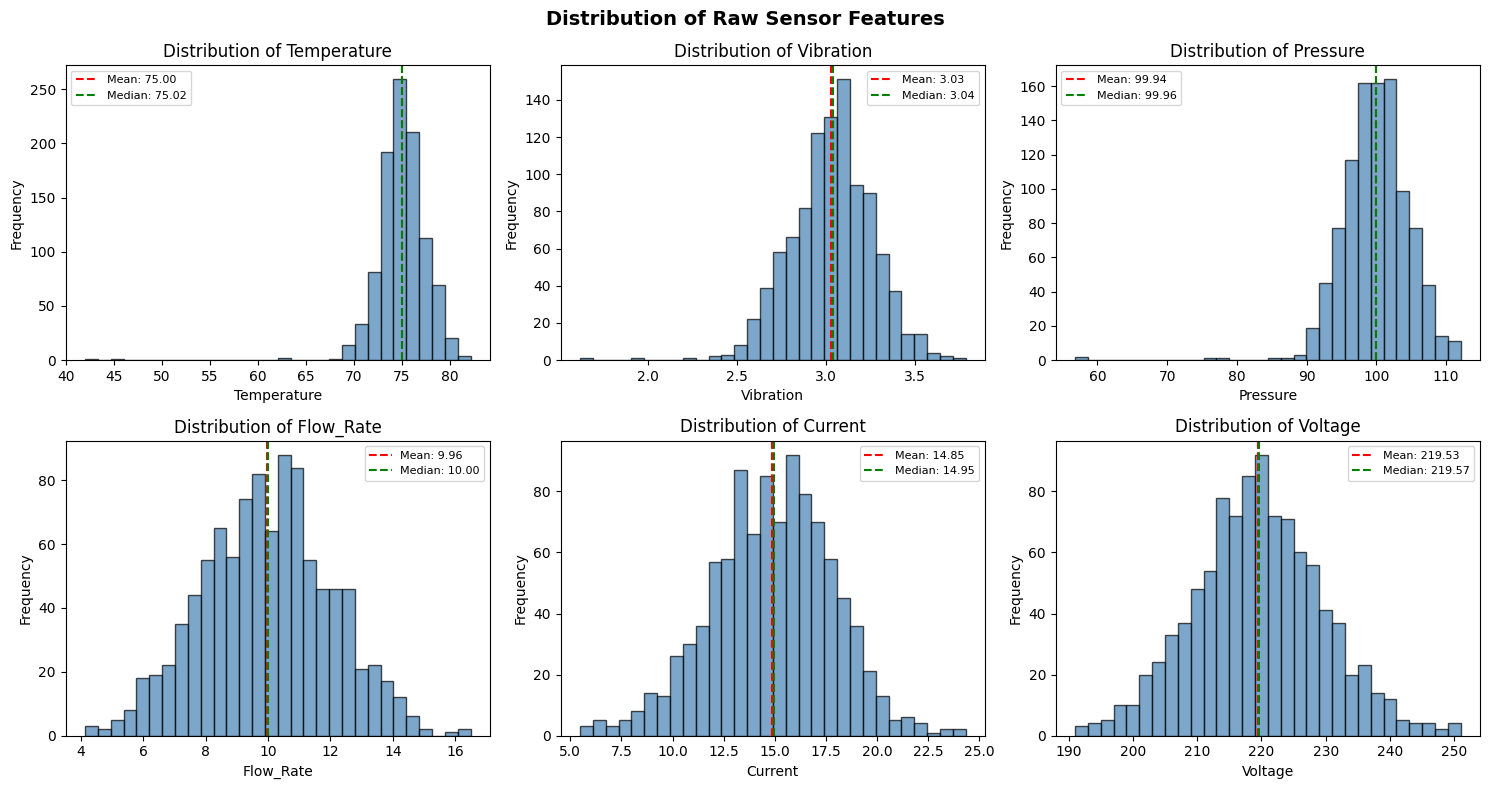


📊 PLOTTING CORRELATION HEATMAP


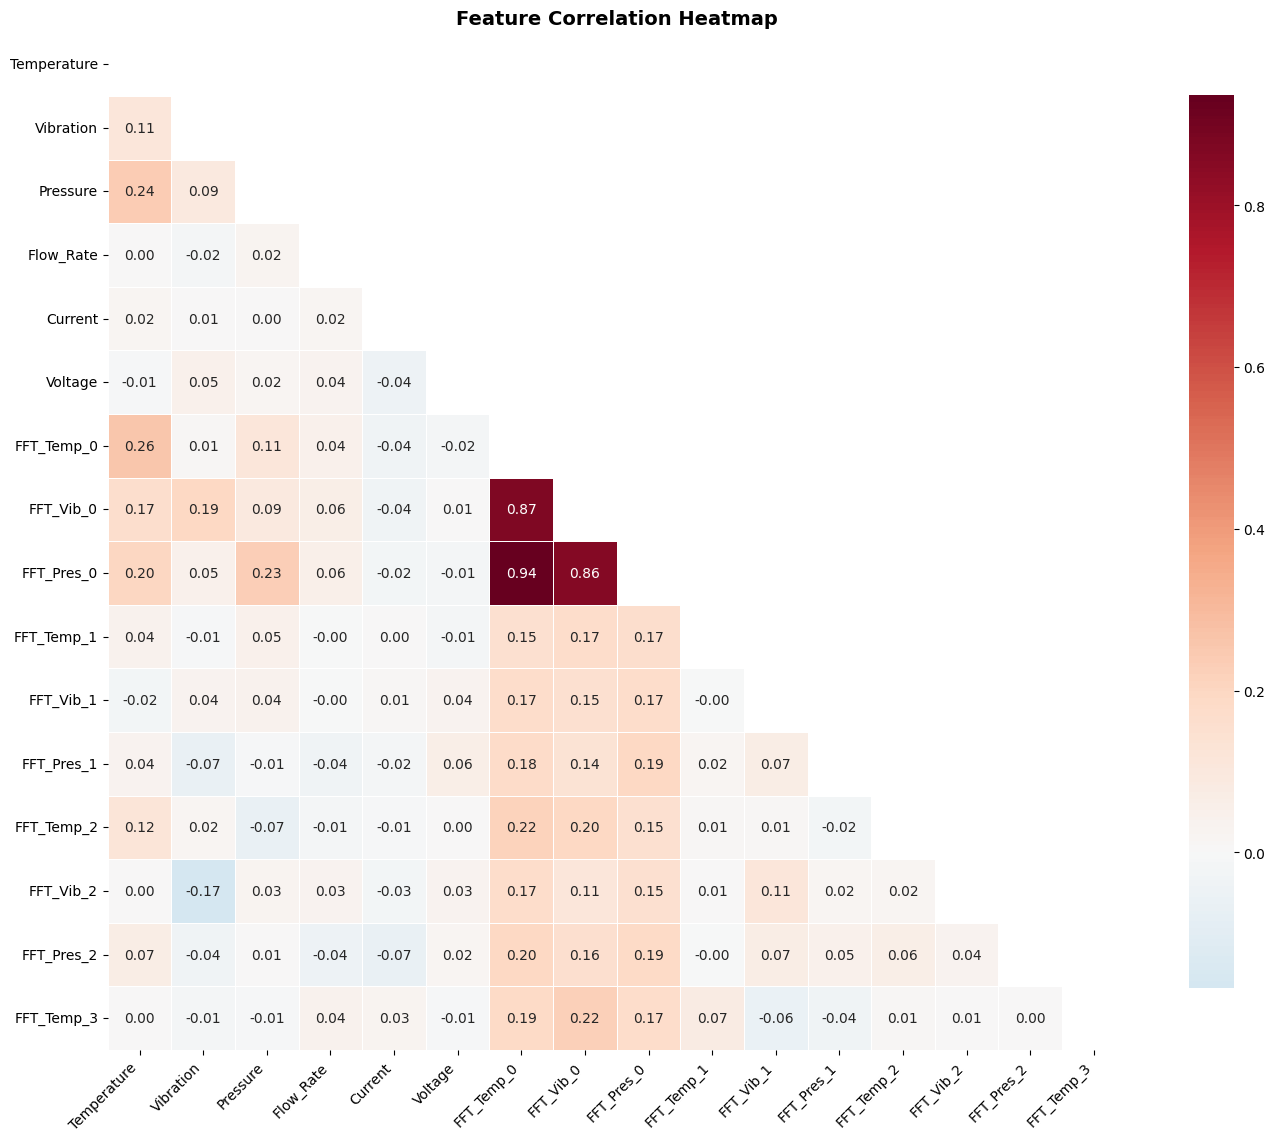


🔧 STEP 2: DATA PREPROCESSING
Raw sensor features: 6
FFT features: 30
Total features: 36

⚠️ Found 10 rows with all zero FFT features
✅ Removed corrupt rows. New shape: (990, 36)

✅ Preprocessing complete! Final shape: (990, 36)

📊 STEP 3: CLASS DISTRIBUTION ANALYSIS

Original class distribution:
   Normal Operation: 717 samples (72.4%)
   Overheating Fault: 90 samples (9.1%)
   Leakage Fault: 94 samples (9.5%)
   Power Fluctuation Fault: 89 samples (9.0%)


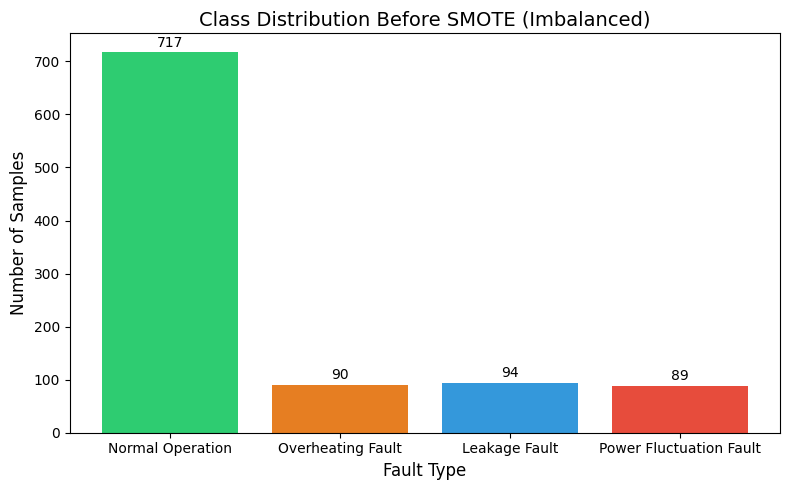


⚖️ STEP 4: APPLYING SMOTE BALANCING

Class distribution AFTER SMOTE:
   Normal Operation: 717 samples
   Overheating Fault: 717 samples
   Leakage Fault: 717 samples
   Power Fluctuation Fault: 717 samples


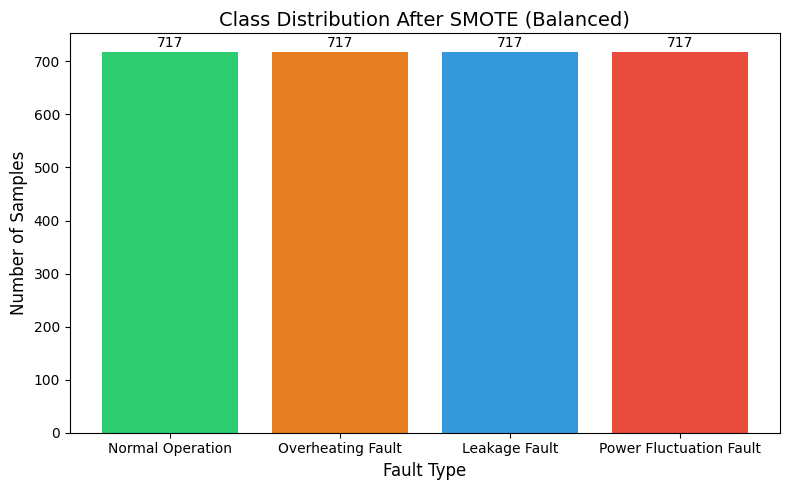


🤖 STEP 5: TRAINING RANDOM FOREST MODEL
Training set: 2294 samples
Test set: 574 samples

Training in progress...
✅ Training complete!

📊 STEP 6: CONFUSION MATRIX ANALYSIS


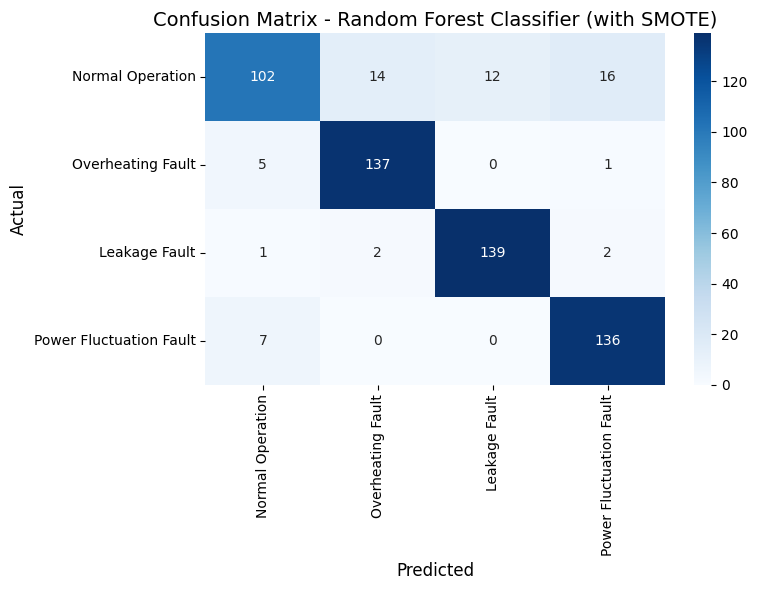


📖 Confusion Matrix Interpretation:
   ✅ Normal Operation correctly classified: 102 out of 144
   ✅ Overheating Fault correctly classified: 137 out of 143
   ✅ Leakage Fault correctly classified: 139 out of 144
   ✅ Power Fluctuation Fault correctly classified: 136 out of 143

📈 STEP 7: CLASSIFICATION REPORT

🎯 Overall Performance Metrics:
   Accuracy: 89.55%
   Precision (macro): 0.8951
   Recall (macro): 0.8957
   F1-Score (macro): 0.8921

📋 Per-Class Performance:
                         precision    recall  f1-score   support

       Normal Operation       0.89      0.71      0.79       144
      Overheating Fault       0.90      0.96      0.93       143
          Leakage Fault       0.92      0.97      0.94       144
Power Fluctuation Fault       0.88      0.95      0.91       143

               accuracy                           0.90       574
              macro avg       0.90      0.90      0.89       574
           weighted avg       0.90      0.90      0.89       574


🔝 STE

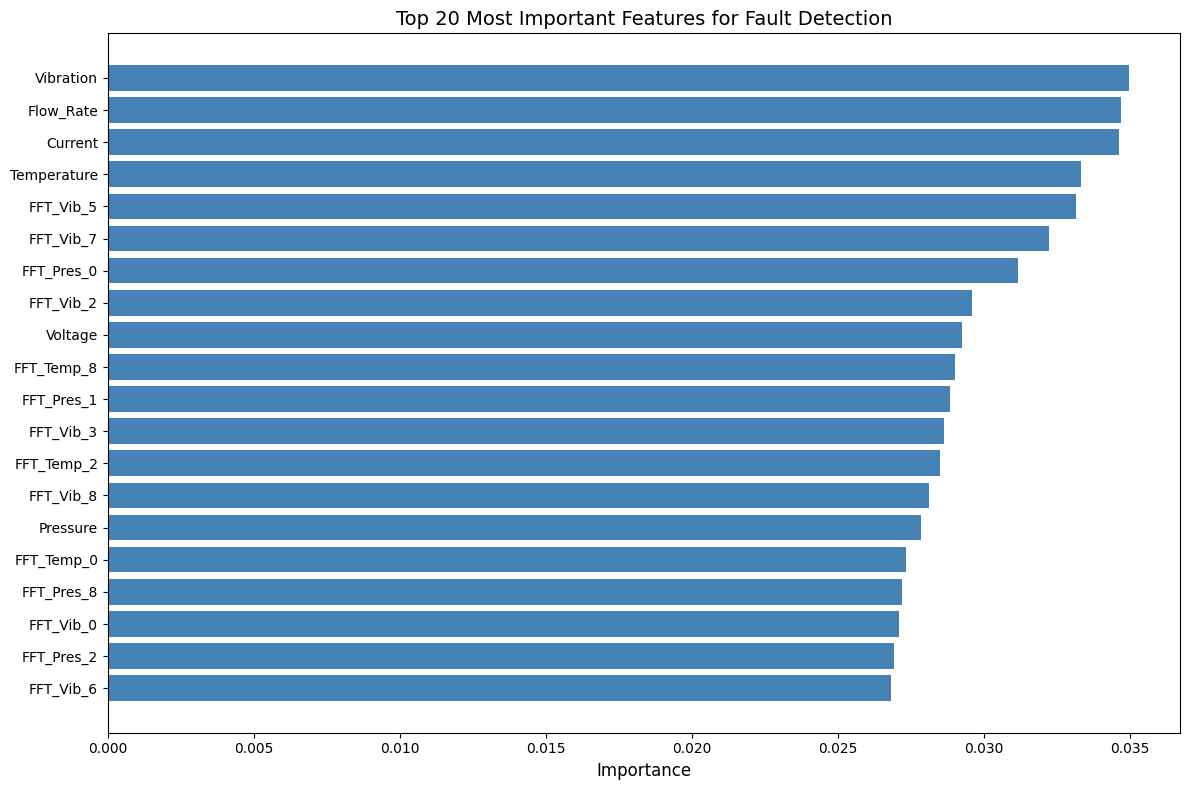


🔍 Top 10 Most Important Features for Fault Detection:
    1. Vibration                      📊 Raw   : 0.0350
    2. Flow_Rate                      📊 Raw   : 0.0347
    3. Current                        📊 Raw   : 0.0346
    4. Temperature                    📊 Raw   : 0.0333
    5. FFT_Vib_5                      🔊 FFT   : 0.0331
    6. FFT_Vib_7                      🔊 FFT   : 0.0322
    7. FFT_Pres_0                     🔊 FFT   : 0.0312
    8. FFT_Vib_2                      🔊 FFT   : 0.0296
    9. Voltage                        📊 Raw   : 0.0292
   10. FFT_Temp_8                     🔊 FFT   : 0.0290

📌 Key Finding: 5/10 top features are FFT features
   -> Frequency-domain analysis is crucial for fault detection!

📊 STEP 9: ROC CURVES ANALYSIS


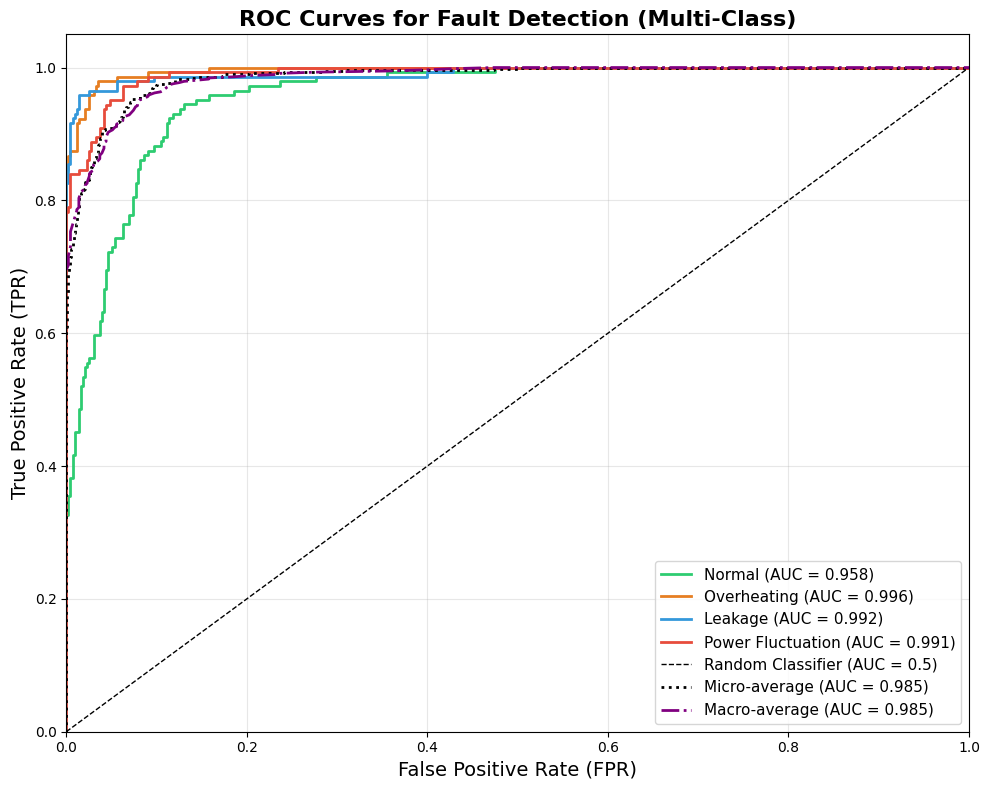


📊 AUC SCORES FOR EACH FAULT TYPE:
   Normal              : AUC = 0.9579
   Overheating         : AUC = 0.9957
   Leakage             : AUC = 0.9918
   Power Fluctuation   : AUC = 0.9911
   Micro-average       : AUC = 0.9855
   Macro-average       : AUC = 0.9847

📊 STEP 10: TRAINING DATA SIGNAL ANALYSIS


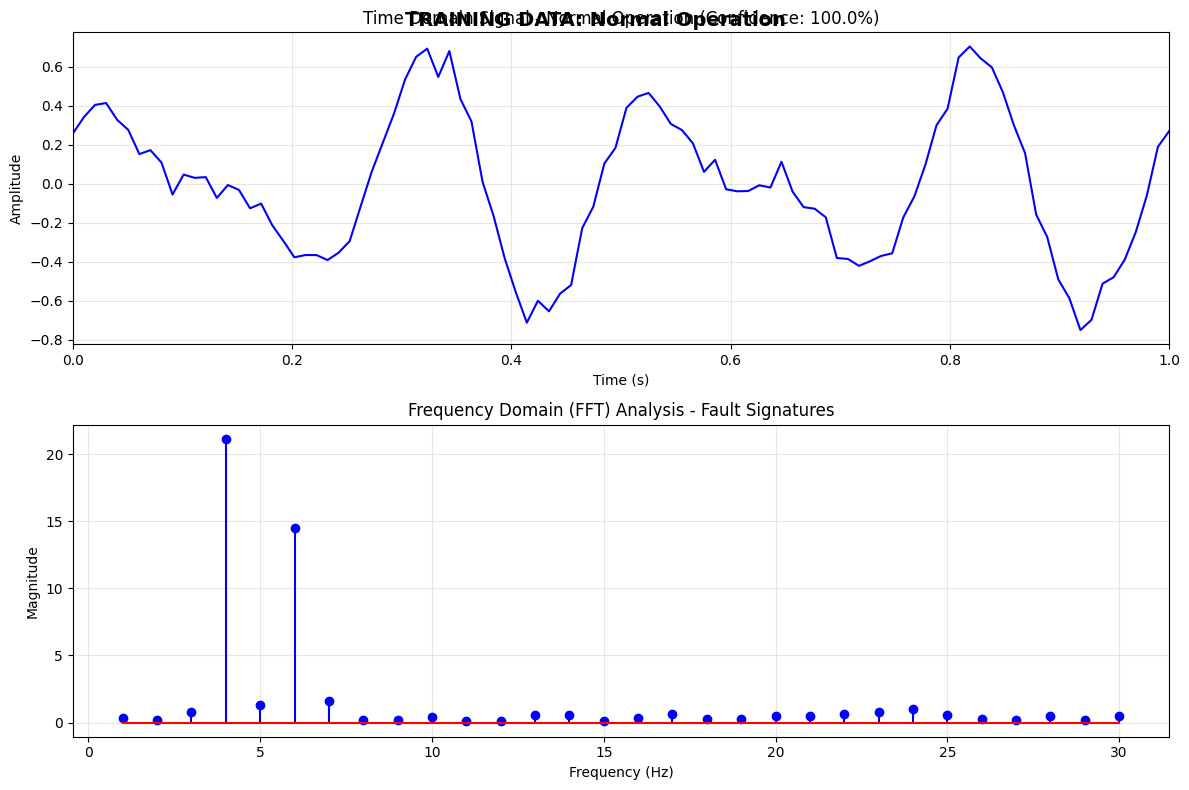

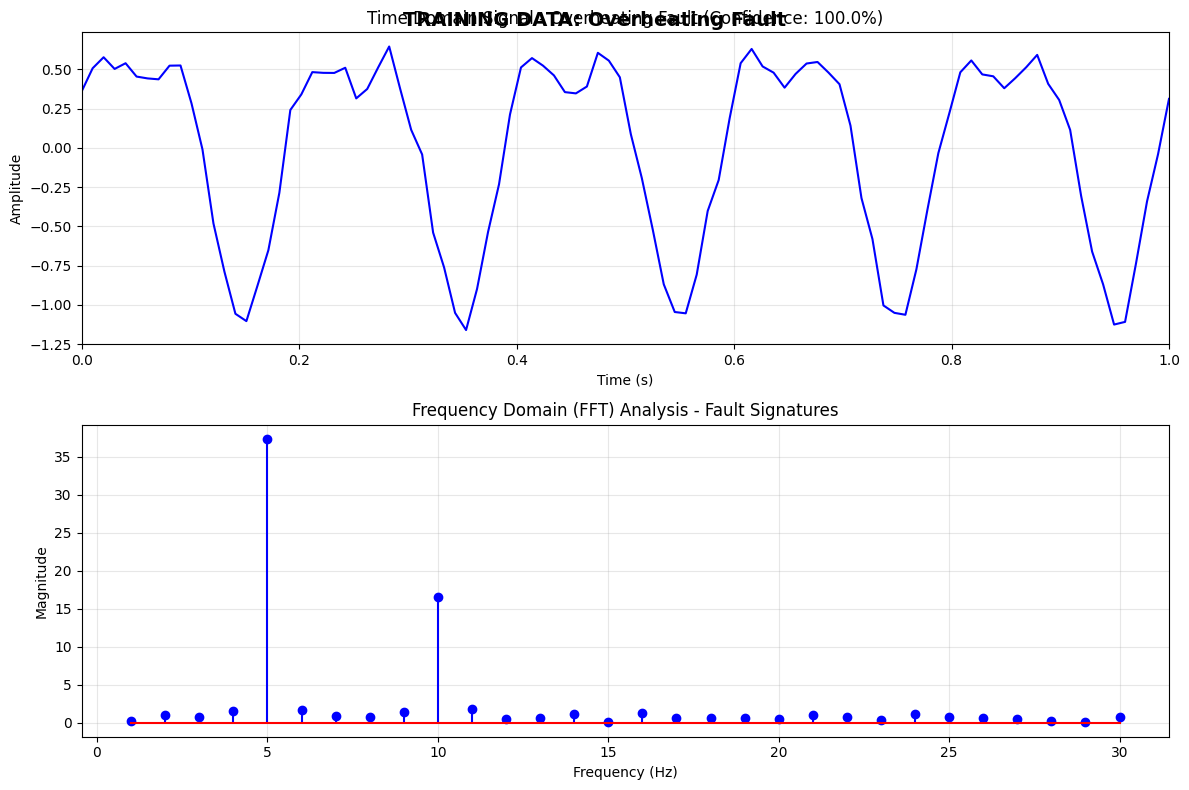

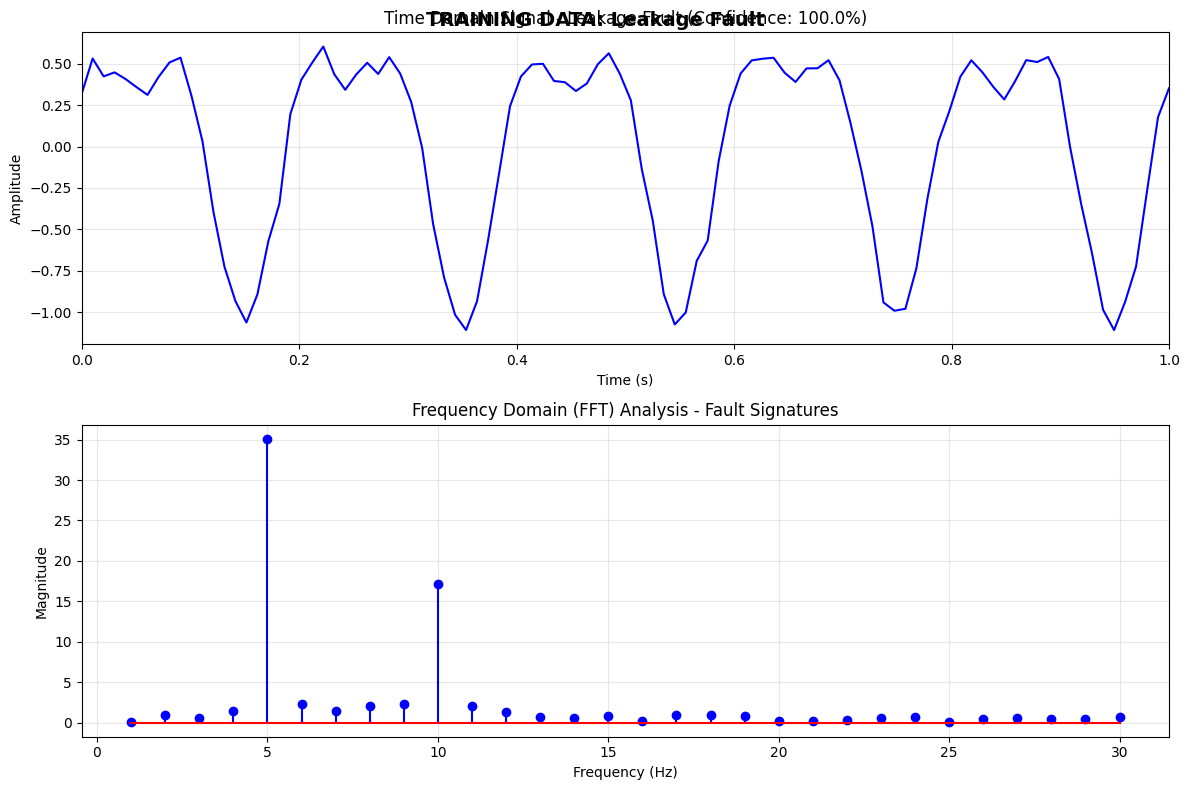

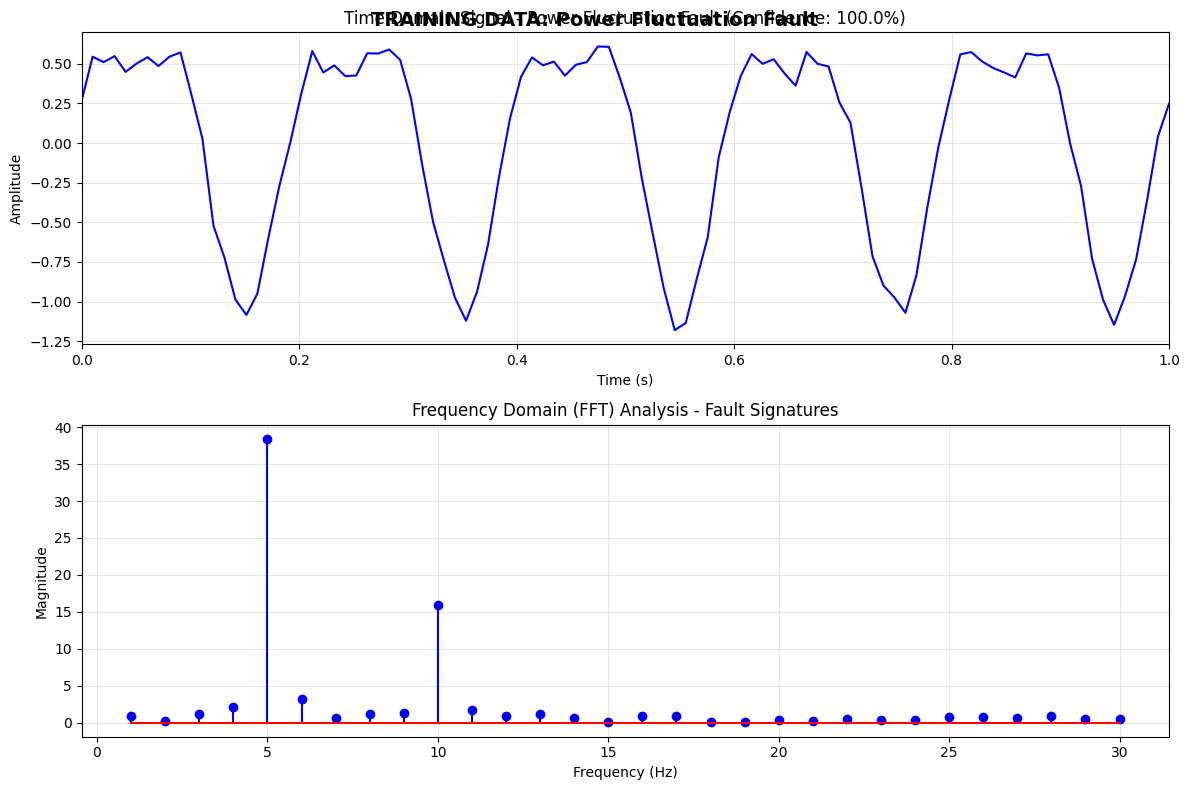


💾 STEP 11: SAVING MODEL
✅ Model saved successfully!

🔧 INDUSTRIAL FAULT DETECTION SYSTEM

🎯 Model Accuracy: 89.55%
📊 F1-Score: 0.8921

📋 MAIN MENU:
   [1] Manual Entry (with signal graphs)
   [2] CSV Batch Prediction
   [3] Test Scenarios
   [4] View Confusion Matrix & Report
   [5] View ROC Curves
   [6] 📥 ADD NEW DATA & RETRAIN MODEL
   [7] Exit

👉 Enter choice (1-7): 2

📁 BATCH PREDICTION FROM CSV

📋 CSV FORMAT (6 columns):
   Temperature,Vibration,Pressure,Flow_Rate,Current,Voltage

📁 Upload your CSV file...


Saving Book1.csv to Book1.csv

✅ Loaded 1 samples

📊 Sample #1

🔍 PREDICTION RESULT

📊 INPUT VALUES:
   Temperature: 46.00613839°C ✅ NORMAL
   Vibration: 2.038361949 ✅ NORMAL
   Pressure: 56.77576627 ⚠️ LOW
   Flow Rate: 6.184384884 ⚠️ LOW
   Current: 12.40951919 A ✅ NORMAL
   Voltage: 215.7624032 V ✅ NORMAL

⚡ ⚡ POWER FLUCTUATION - Check voltage regulator
📈 Confidence: 30.8%
🛡️ Risk Level: 🔴 HIGH - Inspect power supply urgently
💡 Recommendation: Check voltage regulator, UPS system, and power quality.

📉 Probability Distribution:
   Normal Operation    :  29.2% ███████████
   Overheating Fault   :  10.1% ████
   Leakage Fault       :  29.8% ███████████
   Power Fluctuation Fault:  30.8% ████████████


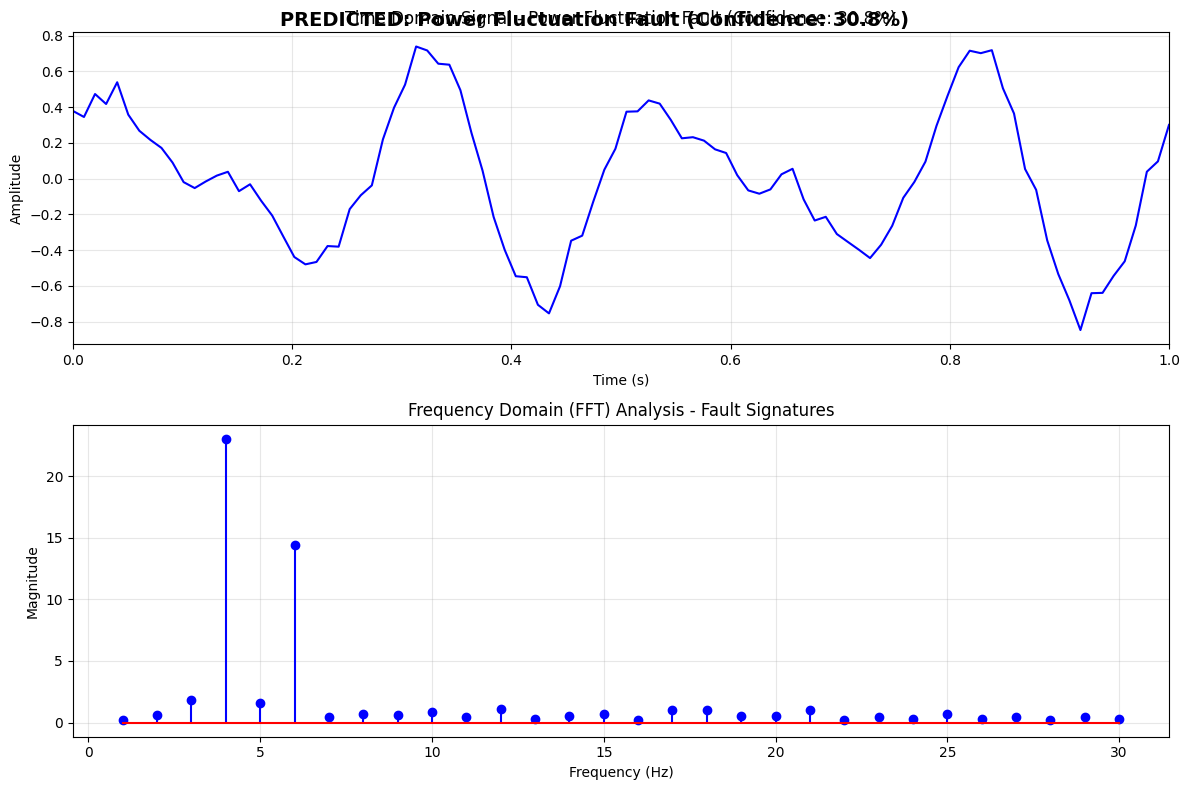


📊 SUMMARY RESULTS
 ID  Temperature  Vibration  Pressure              Prediction Confidence
  1    46.006138   2.038362 56.775766 Power Fluctuation Fault      30.8%

💾 Save results to CSV? (yes/no): no

🔧 INDUSTRIAL FAULT DETECTION SYSTEM

🎯 Model Accuracy: 89.55%
📊 F1-Score: 0.8921

📋 MAIN MENU:
   [1] Manual Entry (with signal graphs)
   [2] CSV Batch Prediction
   [3] Test Scenarios
   [4] View Confusion Matrix & Report
   [5] View ROC Curves
   [6] 📥 ADD NEW DATA & RETRAIN MODEL
   [7] Exit

👉 Enter choice (1-7): 2

📁 BATCH PREDICTION FROM CSV

📋 CSV FORMAT (6 columns):
   Temperature,Vibration,Pressure,Flow_Rate,Current,Voltage

📁 Upload your CSV file...


Saving new_unknown_data.csv to new_unknown_data.csv

✅ Loaded 4 samples

📊 Sample #1

🔍 PREDICTION RESULT

📊 INPUT VALUES:
   Temperature: 42.0°C ✅ NORMAL
   Vibration: 1.98 ✅ NORMAL
   Pressure: 56.77576627 ⚠️ LOW
   Flow Rate: 6.184384884 ⚠️ LOW
   Current: 12.40951919 A ✅ NORMAL
   Voltage: 215.7624032 V ✅ NORMAL

⚡ ⚡ POWER FLUCTUATION - Check voltage regulator
📈 Confidence: 30.8%
🛡️ Risk Level: 🔴 HIGH - Inspect power supply urgently
💡 Recommendation: Check voltage regulator, UPS system, and power quality.

📉 Probability Distribution:
   Normal Operation    :  29.2% ███████████
   Overheating Fault   :  10.1% ████
   Leakage Fault       :  29.8% ███████████
   Power Fluctuation Fault:  30.8% ████████████


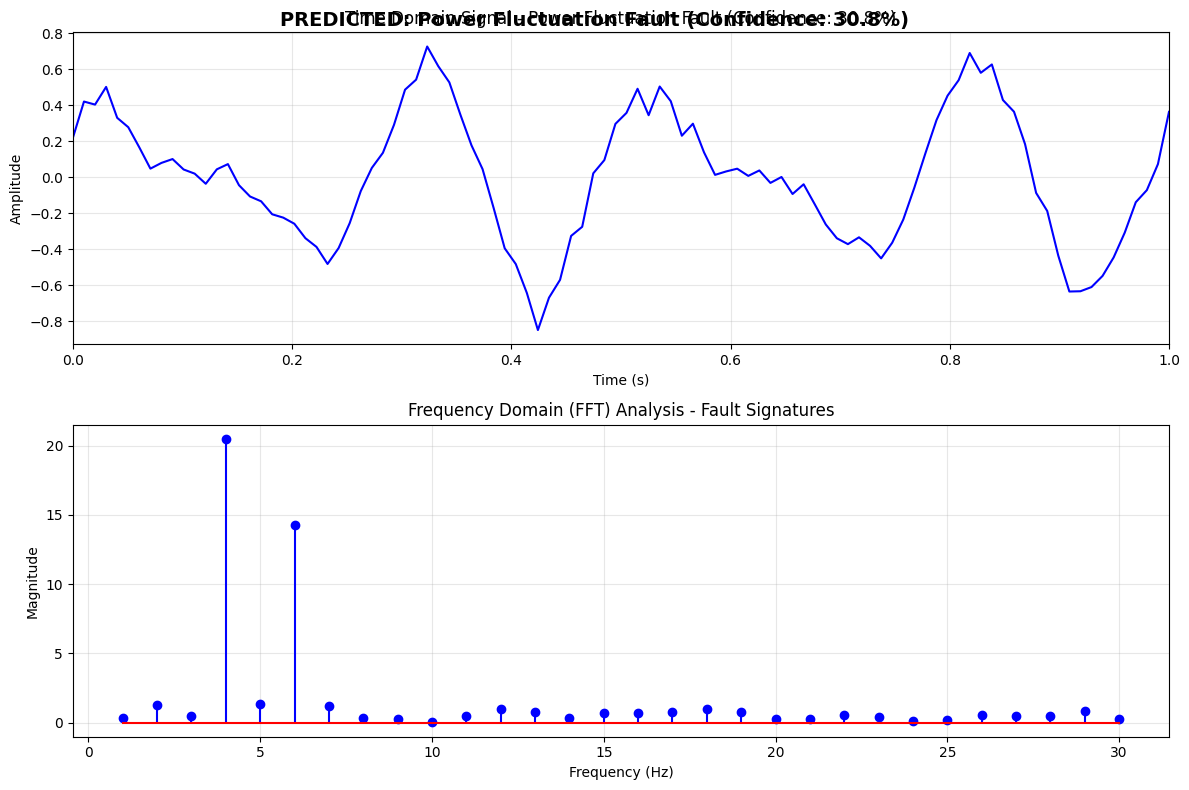


📊 Sample #2

🔍 PREDICTION RESULT

📊 INPUT VALUES:
   Temperature: 62.52916825°C ✅ NORMAL
   Vibration: 2.573668271 ✅ NORMAL
   Pressure: 76.15984321 ⚠️ LOW
   Flow Rate: 8.279229978 ✅ NORMAL
   Current: 14.90638953 A ✅ NORMAL
   Voltage: 215.4658589 V ✅ NORMAL

🟢 ✅ NORMAL OPERATION - No fault detected
📈 Confidence: 29.6%
🛡️ Risk Level: 🟢 LOW - Continue normal operation
💡 Recommendation: Regular monitoring is sufficient. No action needed.

📉 Probability Distribution:
   Normal Operation    :  29.6% ███████████
   Overheating Fault   :  15.1% ██████
   Leakage Fault       :  26.1% ██████████
   Power Fluctuation Fault:  29.1% ███████████


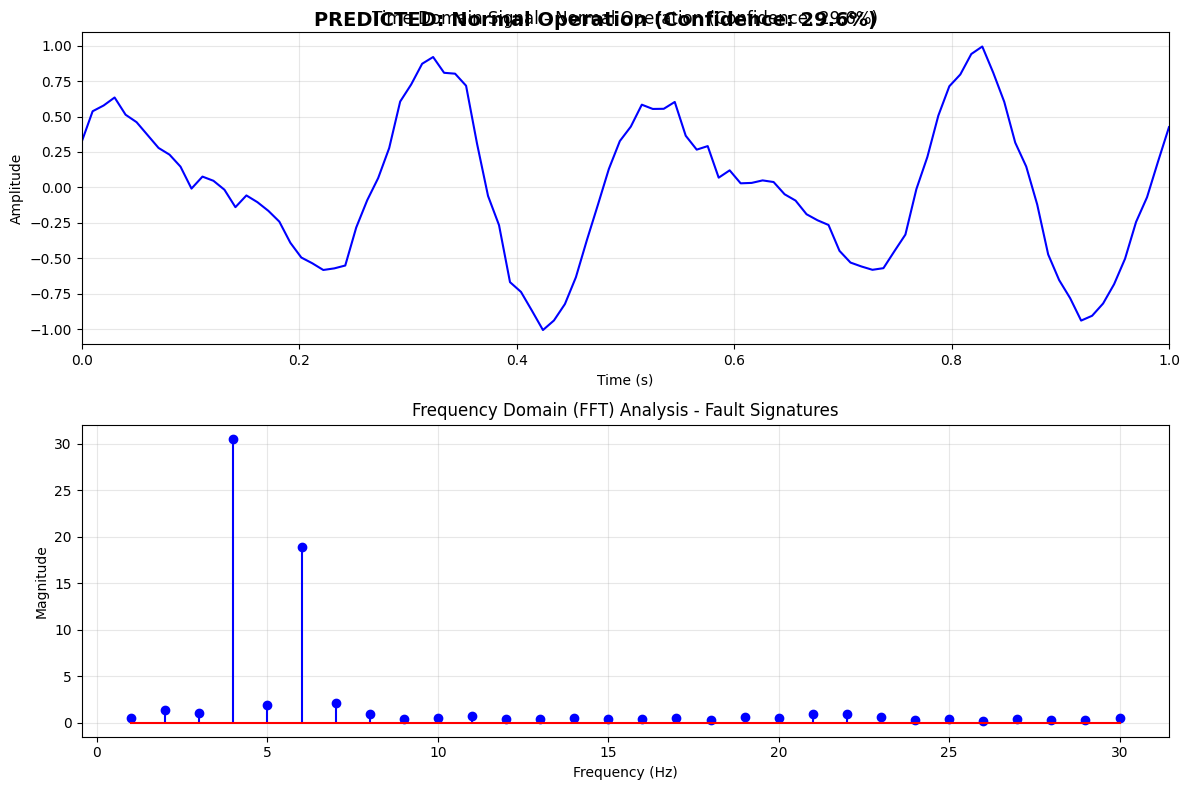


📊 Sample #3

🔍 PREDICTION RESULT

📊 INPUT VALUES:
   Temperature: 77.29501487°C ✅ NORMAL
   Vibration: 3.243490603 ✅ NORMAL
   Pressure: 92.37261387 ✅ NORMAL
   Flow Rate: 9.172788933 ✅ NORMAL
   Current: 15.05405062 A ✅ NORMAL
   Voltage: 202.0435683 V ⚠️ LOW

⚡ ⚡ POWER FLUCTUATION - Check voltage regulator
📈 Confidence: 31.9%
🛡️ Risk Level: 🔴 HIGH - Inspect power supply urgently
💡 Recommendation: Check voltage regulator, UPS system, and power quality.

📉 Probability Distribution:
   Normal Operation    :  21.9% ████████
   Overheating Fault   :  25.1% ██████████
   Leakage Fault       :  21.1% ████████
   Power Fluctuation Fault:  31.9% ████████████


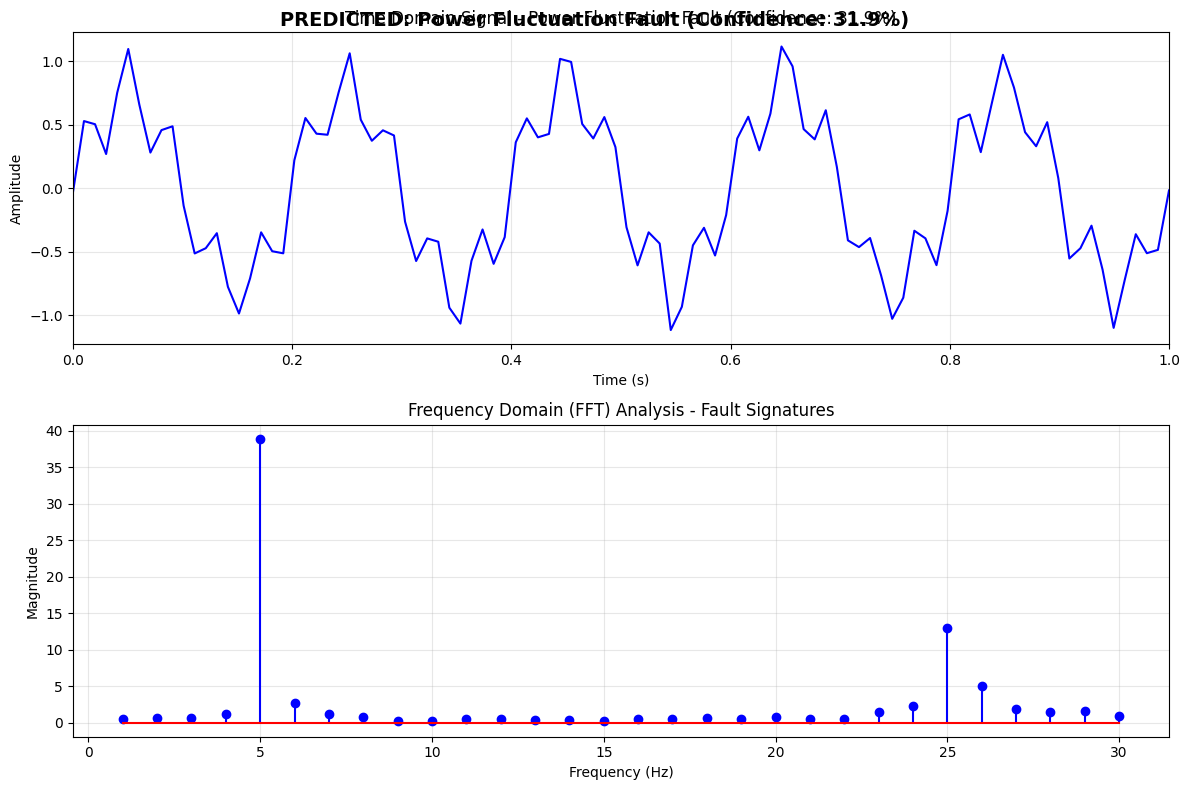


📊 Sample #4

🔍 PREDICTION RESULT

📊 INPUT VALUES:
   Temperature: 76.56416376°C ✅ NORMAL
   Vibration: 3.142903597 ✅ NORMAL
   Pressure: 94.14955784 ✅ NORMAL
   Flow Rate: 13.77537531 ✅ NORMAL
   Current: 16.41789104 A ✅ NORMAL
   Voltage: 216.6990981 V ✅ NORMAL

🔥 🔥 OVERHEATING FAULT - Check cooling system
📈 Confidence: 40.6%
🛡️ Risk Level: 🟠 MEDIUM - Schedule cooling system inspection
💡 Recommendation: Check cooling system, reduce load, inspect thermal sensors.

📉 Probability Distribution:
   Normal Operation    :  21.5% ████████
   Overheating Fault   :  40.6% ████████████████
   Leakage Fault       :  18.1% ███████
   Power Fluctuation Fault:  19.8% ███████


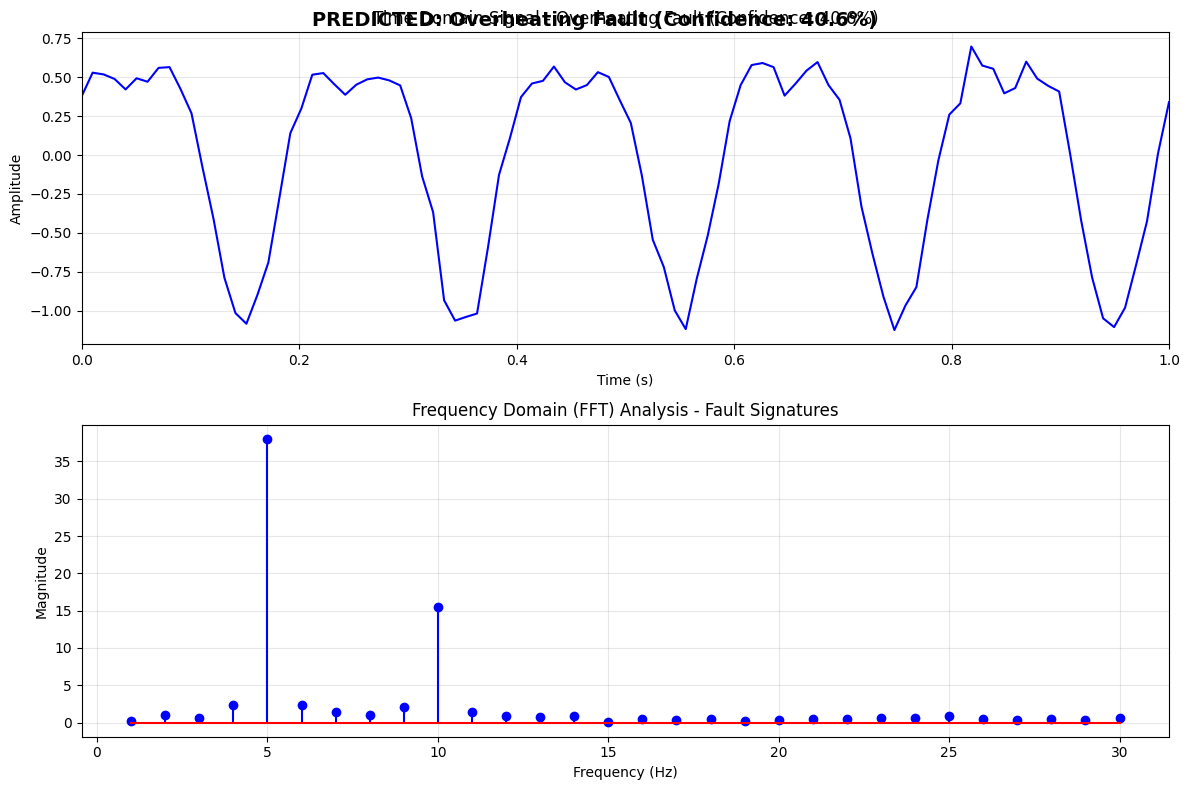


📊 SUMMARY RESULTS
 ID  Temperature  Vibration  Pressure              Prediction Confidence
  1    42.000000   1.980000 56.775766 Power Fluctuation Fault      30.8%
  2    62.529168   2.573668 76.159843        Normal Operation      29.6%
  3    77.295015   3.243491 92.372614 Power Fluctuation Fault      31.9%
  4    76.564164   3.142904 94.149558       Overheating Fault      40.6%

💾 Save results to CSV? (yes/no): no

🔧 INDUSTRIAL FAULT DETECTION SYSTEM

🎯 Model Accuracy: 89.55%
📊 F1-Score: 0.8921

📋 MAIN MENU:
   [1] Manual Entry (with signal graphs)
   [2] CSV Batch Prediction
   [3] Test Scenarios
   [4] View Confusion Matrix & Report
   [5] View ROC Curves
   [6] 📥 ADD NEW DATA & RETRAIN MODEL
   [7] Exit


In [ ]:
# INDUSTRIAL FAULT DETECTION SYSTEM WITH LOADED DATA PREVIEW
# COMPLETE WORKING CODE WITH ROC CURVES

!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
import joblib
import io
import os

print("✅ All libraries loaded!")

# FAULT CATEGORIES

fault_names = {
    0: "Normal Operation",
    1: "Overheating Fault",
    2: "Leakage Fault",
    3: "Power Fluctuation Fault"
}

fault_names_display = {
    0: "✅ NORMAL OPERATION - No fault detected",
    1: "🔥 OVERHEATING FAULT - Check cooling system",
    2: "💧 LEAKAGE FAULT - Inspect pipes and seals",
    3: "⚡ POWER FLUCTUATION - Check voltage regulator"
}

fault_icons = {0: "🟢", 1: "🔥", 2: "💧", 3: "⚡"}

fault_risk = {
    0: "🟢 LOW - Continue normal operation",
    1: "🟠 MEDIUM - Schedule cooling system inspection",
    2: "🟡 MEDIUM-HIGH - Check for leaks immediately",
    3: "🔴 HIGH - Inspect power supply urgently"
}

fault_recommendations = {
    0: "Regular monitoring is sufficient. No action needed.",
    1: "Check cooling system, reduce load, inspect thermal sensors.",
    2: "Inspect pipes, valves, and seals for leaks. Check pump efficiency.",
    3: "Check voltage regulator, UPS system, and power quality."
}

# ============================================================
# ROC CURVE FUNCTION
# ============================================================
def plot_roc_curves(y_test, y_pred_proba, n_classes=4):
    """Plot ROC curves for each fault class"""

    # Binarize the labels for multi-class ROC
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

    # Colors for each class
    colors = ['#2ecc71', '#e67e22', '#3498db', '#e74c3c']
    class_names = ['Normal', 'Overheating', 'Leakage', 'Power Fluctuation']

    plt.figure(figsize=(10, 8))

    # Calculate ROC curve and AUC for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    # Diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')

    # Micro-average ROC curve
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, color='black', lw=2, linestyle=':',
            label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

    # Macro-average ROC curve (average of all classes)
    all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_pred_proba[:, i])[0] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= n_classes
    roc_auc_macro = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, color='purple', lw=2, linestyle='-.',
            label=f'Macro-average (AUC = {roc_auc_macro:.3f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=14)
    plt.ylabel('True Positive Rate (TPR)', fontsize=14)
    plt.title('ROC Curves for Fault Detection (Multi-Class)', fontsize=16, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print AUC scores
    print("\n📊 AUC SCORES FOR EACH FAULT TYPE:")
    print("="*50)
    for i in range(n_classes):
        auc_score = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
        print(f"   {class_names[i]:20s}: AUC = {auc_score:.4f}")
    print(f"   {'Micro-average':20s}: AUC = {roc_auc_micro:.4f}")
    print(f"   {'Macro-average':20s}: AUC = {roc_auc_macro:.4f}")

    return roc_auc_micro, roc_auc_macro

# ============================================================
# NEW: FFT FEATURE GENERATION FROM RAW SIGNALS
# ============================================================
def generate_time_domain_signal_from_sensors(temp, vib, pres, flow, curr, volt, sample_rate=100):
    """Generate synthetic time domain signal from sensor parameters"""
    t = np.linspace(0, 1, sample_rate)

    if temp > 80:  # Overheating pattern
        signal = (temp / 100) * np.sin(2 * np.pi * 8 * t) + \
                 (vib / 10) * np.sin(2 * np.pi * 12 * t) + \
                 0.1 * np.sin(2 * np.pi * 20 * t)
    elif pres < 90:  # Leakage pattern
        signal = (temp / 100) * np.sin(2 * np.pi * 4 * t) + \
                 (pres / 200) * np.cos(2 * np.pi * 6 * t) + \
                 0.05 * np.random.randn(len(t))
    elif volt < 210 or volt > 230:  # Power fluctuation pattern
        signal = (temp / 100) * np.sin(2 * np.pi * 5 * t) + \
                 0.3 * np.sin(2 * np.pi * 25 * t) + \
                 0.15 * np.sin(2 * np.pi * 50 * t)
    else:  # Normal operation
        signal = (temp / 100) * np.sin(2 * np.pi * 5 * t) + \
                 (vib / 10) * np.cos(2 * np.pi * 10 * t) + \
                 0.02 * np.random.randn(len(t))

    noise = np.random.normal(0, 0.03, len(signal))
    signal = signal + noise
    return t, signal

def generate_fft_features_from_signal(signal, sample_rate=100, n_fft_bins=20):
    """Generate FFT features from a time-domain signal"""
    fft_vals = np.fft.fft(signal)
    fft_magnitude = np.abs(fft_vals[:len(signal)//2])
    fft_freq = np.fft.fftfreq(len(signal), 1/sample_rate)[:len(signal)//2]

    # Create FFT features (bin averages)
    bin_size = max(1, len(fft_magnitude) // n_fft_bins)
    fft_features = []
    for i in range(n_fft_bins):
        start = i * bin_size
        end = min(start + bin_size, len(fft_magnitude))
        if start < len(fft_magnitude):
            fft_features.append(np.mean(fft_magnitude[start:end]))
        else:
            fft_features.append(0)

    return fft_features, fft_freq, fft_magnitude

def create_complete_fft_features(temp, vib, pres, flow, curr, volt):
    """Create complete FFT features from sensor readings"""
    t, signal = generate_time_domain_signal_from_sensors(temp, vib, pres, flow, curr, volt)
    fft_features, fft_freq, fft_magnitude = generate_fft_features_from_signal(signal)
    return fft_features, t, signal, fft_freq, fft_magnitude

def plot_new_data_signal(signal, fft_freq, fft_magnitude, fault_name, sample_num=1):
    """Plot time domain and FFT for new data"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    t = np.linspace(0, 1, len(signal))

    # Time Domain
    axes[0].plot(t, signal, 'b-', linewidth=1.5)
    axes[0].set_xlabel('Time (s)', fontsize=12)
    axes[0].set_ylabel('Amplitude', fontsize=12)
    axes[0].set_title(f'Time Domain Signal - New Data Sample #{sample_num}', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1)

    # FFT
    axes[1].stem(fft_freq[:50], fft_magnitude[:50], linefmt='b-', markerfmt='bo', basefmt='r-')
    axes[1].set_xlabel('Frequency (Hz)', fontsize=12)
    axes[1].set_ylabel('Magnitude', fontsize=12)
    axes[1].set_title(f'FFT Analysis - {fault_name}', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# ============================================================
# SIGNAL VISUALIZATION FUNCTIONS
# ============================================================
def generate_time_domain_signal(values, sample_rate=100):
    """Generate a synthetic time domain signal from feature values"""
    t = np.linspace(0, 1, sample_rate)
    if values[0] > 80:
        signal = (values[0] / 100) * np.sin(2 * np.pi * 8 * t) + \
                 (values[1] / 10) * np.sin(2 * np.pi * 12 * t)
    elif values[2] < 90:
        signal = (values[0] / 100) * np.sin(2 * np.pi * 4 * t) + \
                 (values[2] / 200) * np.cos(2 * np.pi * 6 * t)
    elif values[5] < 210 or values[5] > 230:
        signal = (values[0] / 100) * np.sin(2 * np.pi * 5 * t) + \
                 0.3 * np.sin(2 * np.pi * 25 * t)
    else:
        signal = (values[0] / 100) * np.sin(2 * np.pi * 5 * t) + \
                 (values[1] / 10) * np.cos(2 * np.pi * 10 * t)
    noise = np.random.normal(0, 0.05, len(signal))
    signal = signal + noise
    return t, signal

def plot_combined_signals(parameters, fault_name, confidence):
    """Plot both time domain and FFT together"""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    values = list(parameters.values())[:6]
    t, signal = generate_time_domain_signal(values)

    axes[0].plot(t, signal, 'b-', linewidth=1.5)
    axes[0].set_xlabel('Time (s)', fontsize=10)
    axes[0].set_ylabel('Amplitude', fontsize=10)
    axes[0].set_title(f'Time Domain Signal - {fault_name} (Confidence: {confidence:.1f}%)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1)

    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(len(signal), 1/100)
    positive_idx = fft_freq > 0
    axes[1].stem(fft_freq[positive_idx][:30], np.abs(fft_vals[positive_idx][:30]),
                 linefmt='b-', markerfmt='bo', basefmt='r-')
    axes[1].set_xlabel('Frequency (Hz)', fontsize=10)
    axes[1].set_ylabel('Magnitude', fontsize=10)
    axes[1].set_title('Frequency Domain (FFT) Analysis - Fault Signatures', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

# ============================================================
# FUNCTION 1: LOADED DATA PREVIEW
# ============================================================
def preview_loaded_data(df, filename):
    """Display comprehensive preview of loaded data"""
    print("\n" + "="*70)
    print("📊 LOADED DATA PREVIEW")
    print("="*70)
    print(f"\n📁 File Name: {filename}")
    print(f"📏 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    print("\n" + "─"*70)
    print("📋 FIRST 5 ROWS (Preview):")
    print("─"*70)
    print(df.head())

    print("\n" + "─"*70)
    print("📋 LAST 5 ROWS (Preview):")
    print("─"*70)
    print(df.tail())

    print("\n" + "─"*70)
    print("📋 COLUMN INFORMATION:")
    print("─"*70)
    col_info = pd.DataFrame({
        'Column Name': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.count().values,
        'Null Count': df.isnull().sum().values,
        'Unique Values': df.nunique().values
    })
    print(col_info.to_string(index=False))

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        print("\n" + "─"*70)
        print("📊 STATISTICAL SUMMARY (Numeric Columns):")
        print("─"*70)
        print(df[numeric_cols].describe().round(2))

    if 'Fault_Type' in df.columns:
        print("\n" + "─"*70)
        print("📊 FAULT TYPE DISTRIBUTION:")
        print("─"*70)
        fault_counts = df['Fault_Type'].value_counts().sort_index()
        for ft, count in fault_counts.items():
            fault_name = fault_names.get(ft, f"Unknown ({ft})")
            percentage = (count / len(df)) * 100
            bar = "█" * int(percentage / 2)
            print(f"   {ft} -> {fault_name:25s}: {count:4d} samples ({percentage:5.1f}%) {bar}")

    fft_cols = [col for col in df.columns if col.startswith('FFT_')]
    raw_cols = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage']
    existing_raw = [col for col in raw_cols if col in df.columns]

    print("\n" + "─"*70)
    print("🔍 FEATURE COLUMNS ANALYSIS:")
    print("─"*70)
    print(f"   ✅ Raw Sensor Features ({len(existing_raw)}): {existing_raw}")
    print(f"   🔊 FFT Features ({len(fft_cols)}): {fft_cols[:5]}{'...' if len(fft_cols) > 5 else ''}")

    return fft_cols, existing_raw

# ============================================================
# FUNCTION 2: VISUALIZE DATA DISTRIBUTIONS
# ============================================================
def plot_data_distributions(df, existing_raw):
    """Plot histograms of raw sensor features"""
    print("\n" + "="*70)
    print("📊 PLOTTING DATA DISTRIBUTIONS")
    print("="*70)

    plot_cols = [col for col in existing_raw if col in df.columns]
    if plot_cols:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.flatten()
        for i, col in enumerate(plot_cols):
            axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
            axes[i].set_xlabel(col, fontsize=10)
            axes[i].set_ylabel('Frequency', fontsize=10)
            axes[i].set_title(f'Distribution of {col}', fontsize=12)
            axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
            axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
            axes[i].legend(fontsize=8)
        for i in range(len(plot_cols), len(axes)):
            axes[i].set_visible(False)
        plt.suptitle('Distribution of Raw Sensor Features', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No raw sensor columns found for distribution plot")

# ============================================================
# FUNCTION 3: CORRELATION HEATMAP
# ============================================================
def plot_correlation_heatmap(df, existing_raw, fft_cols):
    """Plot correlation heatmap for raw and FFT features"""
    print("\n" + "="*70)
    print("📊 PLOTTING CORRELATION HEATMAP")
    print("="*70)

    selected_cols = existing_raw.copy()
    if fft_cols:
        selected_cols.extend(fft_cols[:10])
    selected_cols = [col for col in selected_cols if col in df.columns]

    if len(selected_cols) > 1:
        plt.figure(figsize=(14, 12))
        correlation_matrix = df[selected_cols].corr()
        mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
        sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
                    cmap='RdBu_r', center=0, square=True,
                    linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Not enough columns for correlation heatmap")

# ============================================================
# NEW FUNCTION: ADD NEW DATA
# ============================================================
def add_new_data_and_retrain():
    """Add new data with automatic FFT generation and retrain model"""
    global df, X, y, X_scaled, rf_model, scaler, mean_fft_values, feature_cols, fft_cols
    global accuracy, f1_macro, precision_macro, recall_macro, cm, y_pred, y_test, y_pred_proba

    print("\n" + "="*70)
    print("📥 ADD NEW DATA TO TRAINED SYSTEM")
    print("="*70)
    print("\nThis feature adds new sensor readings, generates FFT features automatically,")
    print("shows time-domain and FFT graphs, and retrains the model.")

    new_samples = []

    print("\n📊 How would you like to add new data?")
    print("   [1] Manual Entry (single sample)")
    print("   [2] CSV Upload (multiple samples)")

    method = input("\n👉 Enter choice (1-2): ").strip()

    if method == '1':
        print("\n" + "─"*70)
        print("✏️ MANUAL DATA ENTRY")
        print("─"*70)

        try:
            temp = float(input("   Temperature (°C): "))
            vib = float(input("   Vibration: "))
            pres = float(input("   Pressure: "))
            flow = float(input("   Flow Rate: "))
            curr = float(input("   Current (A): "))
            volt = float(input("   Voltage (V): "))

            print("\n📊 Select the TRUE FAULT TYPE:")
            print("   [0] Normal Operation")
            print("   [1] Overheating Fault")
            print("   [2] Leakage Fault")
            print("   [3] Power Fluctuation Fault")
            fault_type = int(input("\n👉 Enter fault type (0-3): "))

            # Generate FFT features
            fft_features, t, signal, fft_freq, fft_magnitude = create_complete_fft_features(temp, vib, pres, flow, curr, volt)

            # Show signal analysis for new data
            print("\n📊 NEW DATA SIGNAL ANALYSIS:")
            fig = plot_new_data_signal(signal, fft_freq, fft_magnitude, fault_names[fault_type], 1)
            plt.suptitle('NEW DATA: Time Domain and FFT Analysis', fontsize=14, fontweight='bold')
            plt.show()

            # Create sample
            sample = {
                'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
                'Flow_Rate': flow, 'Current': curr, 'Voltage': volt, 'Fault_Type': fault_type
            }
            for i, ff_val in enumerate(fft_features[:len(fft_cols)]):
                sample[f'FFT_{i+1}'] = ff_val
            new_samples.append(sample)
            print(f"\n✅ New sample prepared!")

        except ValueError:
            print("❌ Invalid input!")
            return

    elif method == '2':
        print("\n📁 Upload CSV file with new data")
        print("\n📋 CSV FORMAT REQUIRED:")
        print("   Temperature,Vibration,Pressure,Flow_Rate,Current,Voltage,Fault_Type")

        uploaded = files.upload()
        if not uploaded:
            print("❌ No file uploaded")
            return

        filename = list(uploaded.keys())[0]
        new_df = pd.read_csv(filename)
        print(f"\n✅ Loaded {len(new_df)} samples")

        for idx, row in new_df.iterrows():
            temp = row['Temperature']
            vib = row['Vibration']
            pres = row['Pressure']
            flow = row['Flow_Rate']
            curr = row['Current']
            volt = row['Voltage']
            fault_type = row.get('Fault_Type', 0)

            fft_features, t, signal, fft_freq, fft_magnitude = create_complete_fft_features(temp, vib, pres, flow, curr, volt)

            sample = {
                'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
                'Flow_Rate': flow, 'Current': curr, 'Voltage': volt, 'Fault_Type': fault_type
            }
            for i, ff_val in enumerate(fft_features[:len(fft_cols)]):
                sample[f'FFT_{i+1}'] = ff_val
            new_samples.append(sample)

            # Show first 3 samples
            if idx < 3:
                print(f"\n📊 Sample #{idx+1} Signal Analysis:")
                fig = plot_new_data_signal(signal, fft_freq, fft_magnitude, fault_names[fault_type], idx+1)
                plt.suptitle(f'NEW DATA SAMPLE #{idx+1}', fontsize=14, fontweight='bold')
                plt.show()

        print(f"\n✅ Processed {len(new_samples)} new samples!")

    if not new_samples:
        print("❌ No new samples to add")
        return

    new_df = pd.DataFrame(new_samples)

    # Ensure all FFT columns exist
    for i, col in enumerate(fft_cols):
        if col not in new_df.columns:
            new_df[col] = 0

    print("\n" + "─"*70)
    print("📊 NEW DATA SUMMARY:")
    print("─"*70)
    print(new_df[['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage', 'Fault_Type']].head())

    confirm = input(f"\n⚠️ Add {len(new_samples)} new sample(s) and RETRAIN the model? (yes/no): ").lower()
    if confirm != 'yes':
        print("❌ Operation cancelled")
        return

    # Merge and retrain
    print("\n🔄 Merging new data with existing dataset...")

    # Get original data columns
    original_data = pd.DataFrame(X.copy())
    original_data['Fault_Type'] = y.copy()

    # Ensure column alignment
    for col in fft_cols:
        if col not in original_data.columns:
            original_data[col] = 0

    combined_df = pd.concat([original_data, new_df], ignore_index=True)
    print(f"✅ Combined dataset: {combined_df.shape[0]} samples")

    # Retrain
    print("\n🔄 RETRAINING MODEL WITH NEW DATA...")

    feature_cols_new = [col for col in combined_df.columns if col != 'Fault_Type']
    X_new = combined_df[feature_cols_new].copy()
    y_new = combined_df['Fault_Type'].copy()

    X_new = X_new.fillna(X_new.mean())
    X_new = X_new.replace([np.inf, -np.inf], np.nan)
    X_new = X_new.fillna(X_new.mean())

    scaler_new = StandardScaler()
    X_scaled_new = scaler_new.fit_transform(X_new)

    smote = SMOTE(random_state=42)
    X_balanced_new, y_balanced_new = smote.fit_resample(X_scaled_new, y_new)

    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
        X_balanced_new, y_balanced_new, test_size=0.2, random_state=42, stratify=y_balanced_new
    )

    rf_model_new = RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=10,
        min_samples_leaf=4, random_state=42, n_jobs=-1
    )
    rf_model_new.fit(X_train_new, y_train_new)

    y_pred_new = rf_model_new.predict(X_test_new)
    y_pred_proba_new = rf_model_new.predict_proba(X_test_new)
    accuracy_new = accuracy_score(y_test_new, y_pred_new)
    f1_macro_new = f1_score(y_test_new, y_pred_new, average='macro')

    # Update global variables
    df = combined_df
    X = X_new
    y = y_new
    X_scaled = X_scaled_new
    rf_model = rf_model_new
    scaler = scaler_new
    feature_cols = feature_cols_new
    accuracy = accuracy_new
    f1_macro = f1_macro_new
    precision_macro = precision_score(y_test_new, y_pred_new, average='macro')
    recall_macro = recall_score(y_test_new, y_pred_new, average='macro')
    cm = confusion_matrix(y_test_new, y_pred_new)
    y_pred = y_pred_new
    y_test = y_test_new
    y_pred_proba = y_pred_proba_new

    # Update mean FFT values
    mean_fft_values = {}
    for col in [c for c in feature_cols if c.startswith('FFT_')]:
        mean_fft_values[col] = X[col].mean()

    print("\n" + "="*70)
    print("✅ MODEL RETRAINING COMPLETE!")
    print("="*70)
    print(f"\n📊 UPDATED MODEL PERFORMANCE:")
    print(f"   Accuracy: {accuracy*100:.2f}%")
    print(f"   F1-Score: {f1_macro:.4f}")
    print(f"   Precision: {precision_macro:.4f}")
    print(f"   Recall: {recall_macro:.4f}")

    # Show updated confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'],
                yticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'])
    plt.title('UPDATED Confusion Matrix (After Adding New Data)', fontsize=14)
    plt.show()

    # Show ROC curves for updated model
    print("\n📊 UPDATED ROC CURVES:")
    plot_roc_curves(y_test, y_pred_proba)

    # Save updated model
    joblib.dump(rf_model, 'fault_detection_model_updated.pkl')
    joblib.dump(scaler, 'scaler_updated.pkl')
    joblib.dump(mean_fft_values, 'mean_fft_values_updated.pkl')
    joblib.dump(feature_cols, 'feature_cols_updated.pkl')
    print("\n💾 Updated model saved as 'fault_detection_model_updated.pkl'")

    return True

# ============================================================
# PREDICTION FUNCTIONS
# ============================================================

def predict_with_signals(temp, vib, pres, flow, curr, volt):
    """Predict fault and display time domain + FFT graphs"""
    params = {
        'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
        'Flow_Rate': flow, 'Current': curr, 'Voltage': volt
    }

    input_dict = {
        'Temperature': temp, 'Vibration': vib, 'Pressure': pres,
        'Flow_Rate': flow, 'Current': curr, 'Voltage': volt
    }

    for col in fft_cols:
        input_dict[col] = mean_fft_values.get(col, 0)

    input_df = pd.DataFrame([input_dict])
    input_df = input_df[feature_cols]
    input_scaled = scaler.transform(input_df)

    prediction = rf_model.predict(input_scaled)[0]
    probabilities = rf_model.predict_proba(input_scaled)[0]
    confidence = probabilities[prediction] * 100

    print("\n" + "="*70)
    print("🔍 PREDICTION RESULT")
    print("="*70)
    print(f"\n📊 INPUT VALUES:")
    print(f"   Temperature: {temp}°C", "⚠️ HIGH" if temp > 80 else "✅ NORMAL")
    print(f"   Vibration: {vib}", "⚠️ HIGH" if vib > 3.5 else "✅ NORMAL")
    print(f"   Pressure: {pres}", "⚠️ LOW" if pres < 90 else "⚠️ HIGH" if pres > 105 else "✅ NORMAL")
    print(f"   Flow Rate: {flow}", "⚠️ LOW" if flow < 8 else "✅ NORMAL")
    print(f"   Current: {curr} A", "⚠️ HIGH" if curr > 18 else "✅ NORMAL")
    print(f"   Voltage: {volt} V", "⚠️ LOW" if volt < 210 else "⚠️ HIGH" if volt > 230 else "✅ NORMAL")

    print(f"\n{fault_icons.get(prediction, '?')} {fault_names_display.get(prediction, f'UNKNOWN FAULT ({prediction})')}")
    print(f"📈 Confidence: {confidence:.1f}%")
    print(f"🛡️ Risk Level: {fault_risk.get(prediction, '? UNKNOWN')}")
    print(f"💡 Recommendation: {fault_recommendations.get(prediction, 'Please consult maintenance manual.')}")

    print("\n📉 Probability Distribution:")
    for i, prob in enumerate(probabilities[:4]):
        bar = "█" * int(prob * 40)
        class_name = fault_names.get(i, f"Class {i}")
        print(f"   {class_name:20s}: {prob*100:5.1f}% {bar}")

    fig = plot_combined_signals(params, fault_names.get(prediction, "Unknown Fault"), confidence)
    plt.suptitle(f'PREDICTED: {fault_names.get(prediction, "Unknown Fault")} (Confidence: {confidence:.1f}%)',
                 fontsize=14, fontweight='bold')
    plt.show()
    return prediction, probabilities

def batch_prediction():
    print("\n" + "="*70)
    print("📁 BATCH PREDICTION FROM CSV")
    print("="*70)
    print("\n📋 CSV FORMAT (6 columns):")
    print("   Temperature,Vibration,Pressure,Flow_Rate,Current,Voltage")

    print("\n📁 Upload your CSV file...")
    uploaded = files.upload()
    if not uploaded:
        print("❌ No file uploaded")
        return

    filename = list(uploaded.keys())[0]
    new_data = pd.read_csv(filename)
    print(f"\n✅ Loaded {len(new_data)} samples")

    results = []
    for i in range(len(new_data)):
        temp = new_data['Temperature'].iloc[i]
        vib = new_data['Vibration'].iloc[i]
        pres = new_data['Pressure'].iloc[i]
        flow = new_data['Flow_Rate'].iloc[i]
        curr = new_data['Current'].iloc[i]
        volt = new_data['Voltage'].iloc[i]

        print(f"\n{'='*60}")
        print(f"📊 Sample #{i+1}")
        print(f"{'='*60}")
        pred, probs = predict_with_signals(temp, vib, pres, flow, curr, volt)
        results.append({'ID': i+1, 'Temperature': temp, 'Vibration': vib,
                       'Pressure': pres, 'Prediction': fault_names.get(pred, "Unknown"),
                       'Confidence': f"{probs[pred]*100:.1f}%"})

    print("\n" + "="*70)
    print("📊 SUMMARY RESULTS")
    print("="*70)
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    save = input("\n💾 Save results to CSV? (yes/no): ").lower()
    if save == 'yes':
        results_df.to_csv('batch_results.csv', index=False)
        files.download('batch_results.csv')
        print("✅ Results saved!")

def manual_prediction():
    print("\n" + "="*70)
    print("✏️ MANUAL PREDICTION MODE")
    print("="*70)
    print("\n📋 NORMAL OPERATING RANGES:")
    print("   Temperature: 70-80°C | Vibration: 2.5-3.5")
    print("   Pressure: 90-105 | Flow Rate: 8-12")
    print("   Current: 12-18 A | Voltage: 210-230 V")

    count = 0
    while True:
        count += 1
        print(f"\n📊 MACHINE #{count}")
        print("-"*40)
        try:
            temp = float(input("   Temperature (°C): "))
            vib = float(input("   Vibration: "))
            pres = float(input("   Pressure: "))
            flow = float(input("   Flow Rate: "))
            curr = float(input("   Current (A): "))
            volt = float(input("   Voltage (V): "))
            predict_with_signals(temp, vib, pres, flow, curr, volt)
            another = input("\n🔁 Predict another machine? (yes/no): ").lower()
            if another != 'yes':
                break
        except ValueError:
            print("❌ Invalid input! Please enter numeric values.")

def test_scenarios():
    print("\n" + "="*70)
    print("🧪 TEST SCENARIOS")
    print("="*70)
    test_cases = [
        {"name": "NORMAL OPERATION", "temp": 75, "vib": 3.0, "pres": 100, "flow": 10, "curr": 15, "volt": 220},
        {"name": "OVERHEATING FAULT", "temp": 85, "vib": 4.0, "pres": 102, "flow": 11, "curr": 24, "volt": 220},
        {"name": "LEAKAGE FAULT", "temp": 74, "vib": 3.2, "pres": 82, "flow": 6.5, "curr": 16, "volt": 218},
        {"name": "POWER FLUCTUATION", "temp": 76, "vib": 3.3, "pres": 100, "flow": 10, "curr": 14, "volt": 205},
    ]
    for case in test_cases:
        print(f"\n{'='*60}")
        print(f"Testing: {case['name']}")
        print(f"{'='*60}")
        predict_with_signals(case['temp'], case['vib'], case['pres'],
                            case['flow'], case['curr'], case['volt'])

# ============================================================
# COMPLETE MAIN MENU WITH ROC OPTION
# ============================================================
def main_menu():
    while True:
        print("\n" + "="*70)
        print("🔧 INDUSTRIAL FAULT DETECTION SYSTEM")
        print("="*70)
        print(f"\n🎯 Model Accuracy: {accuracy*100:.2f}%")
        print(f"📊 F1-Score: {f1_macro:.4f}")
        print("\n📋 MAIN MENU:")
        print("   [1] Manual Entry (with signal graphs)")
        print("   [2] CSV Batch Prediction")
        print("   [3] Test Scenarios")
        print("   [4] View Confusion Matrix & Report")
        print("   [5] View ROC Curves")  # NEW!
        print("   [6] 📥 ADD NEW DATA & RETRAIN MODEL")
        print("   [7] Exit")

        choice = input("\n👉 Enter choice (1-7): ").strip()

        if choice == '1':
            manual_prediction()
        elif choice == '2':
            batch_prediction()
        elif choice == '3':
            test_scenarios()
        elif choice == '4':
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'],
                        yticklabels=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation'])
            plt.title('Confusion Matrix', fontsize=14)
            plt.show()
            print(f"\n📊 Performance Summary:")
            print(f"   Accuracy: {accuracy*100:.2f}%")
            print(f"   F1-Score: {f1_macro:.4f}")
            print(f"   Precision: {precision_macro:.4f}")
            print(f"   Recall: {recall_macro:.4f}")
            print("\n📋 Classification Report:")
            print(classification_report(y_test, y_pred,
                                       target_names=['Normal', 'Overheating', 'Leakage', 'Power Fluctuation']))
            input("\nPress Enter to continue...")
        elif choice == '5':
            # NEW: Show ROC Curves
            print("\n" + "="*70)
            print("📊 ROC CURVES ANALYSIS")
            print("="*70)
            plot_roc_curves(y_test, y_pred_proba)
            input("\nPress Enter to continue...")
        elif choice == '6':
            add_new_data_and_retrain()
        elif choice == '7':
            print("\n" + "="*70)
            print("✅ Thank you for using the Fault Detection System!")
            print("👋 Goodbye!")
            print("="*70)
            break
        else:
            print("❌ Invalid choice. Please enter 1-7.")

# ============================================================
# MAIN EXECUTION
# ============================================================

print("\n" + "="*70)
print("📁 STEP 1: UPLOAD YOUR TRAINING DATASET")
print("="*70)
print("Please upload your CSV file (Industrial_fault_detection (1).csv)")

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# DISPLAY LOADED DATA PREVIEW
fft_cols, existing_raw = preview_loaded_data(df, filename)

# PLOT DATA DISTRIBUTIONS
plot_data_distributions(df, existing_raw)

# PLOT CORRELATION HEATMAP
plot_correlation_heatmap(df, existing_raw, fft_cols)

# DATA PREPROCESSING
print("\n" + "="*70)
print("🔧 STEP 2: DATA PREPROCESSING")
print("="*70)

feature_cols = [col for col in df.columns if col != 'Fault_Type']
X = df[feature_cols].copy()
y = df['Fault_Type'].copy()

if 'fft_cols' not in dir():
    fft_cols = [col for col in feature_cols if col.startswith('FFT_')]
raw_cols = ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage']
existing_raw = [col for col in raw_cols if col in df.columns]

print(f"Raw sensor features: {len(existing_raw)}")
print(f"FFT features: {len(fft_cols)}")
print(f"Total features: {len(feature_cols)}")

if fft_cols:
    zero_fft_rows = (X[fft_cols] == 0).all(axis=1).sum()
    if zero_fft_rows > 0:
        print(f"\n⚠️ Found {zero_fft_rows} rows with all zero FFT features")
        mask = ~(X[fft_cols] == 0).all(axis=1)
        X = X[mask]
        y = y[mask]
        print(f"✅ Removed corrupt rows. New shape: {X.shape}")

X = X.fillna(X.mean())
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

if fft_cols:
    mean_fft_values = {}
    for col in fft_cols:
        mean_fft_values[col] = X[col].mean()
else:
    mean_fft_values = {}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Preprocessing complete! Final shape: {X_scaled.shape}")

# CLASS DISTRIBUTION (BEFORE SMOTE)
print("\n" + "="*70)
print("📊 STEP 3: CLASS DISTRIBUTION ANALYSIS")
print("="*70)

fault_counts = y.value_counts().sort_index()
print("\nOriginal class distribution:")
for ft, count in fault_counts.items():
    print(f"   {fault_names.get(ft, f'Unknown ({ft})')}: {count} samples ({count/len(y)*100:.1f}%)")

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e67e22', '#3498db', '#e74c3c']
bars = plt.bar(fault_counts.index, fault_counts.values, color=colors[:len(fault_counts)])
plt.xlabel('Fault Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution Before SMOTE (Imbalanced)', fontsize=14)
plt.xticks(sorted(fault_counts.index), [fault_names.get(ft, ft) for ft in sorted(fault_counts.index)])
for bar, count in zip(bars, fault_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{count}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# APPLY SMOTE
print("\n" + "="*70)
print("⚖️ STEP 4: APPLYING SMOTE BALANCING")
print("="*70)

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

balanced_counts = pd.Series(y_balanced).value_counts().sort_index()
print("\nClass distribution AFTER SMOTE:")
for ft, count in balanced_counts.items():
    print(f"   {fault_names.get(ft, f'Unknown ({ft})')}: {count} samples")

plt.figure(figsize=(8, 5))
bars = plt.bar(balanced_counts.index, balanced_counts.values, color=colors[:len(balanced_counts)])
plt.xlabel('Fault Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution After SMOTE (Balanced)', fontsize=14)
plt.xticks(sorted(balanced_counts.index), [fault_names.get(ft, ft) for ft in sorted(balanced_counts.index)])
for bar, count in zip(bars, balanced_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{count}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# TRAIN-TEST SPLIT
print("\n" + "="*70)
print("🤖 STEP 5: TRAINING RANDOM FOREST MODEL")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=4, random_state=42, n_jobs=-1
)

print("\nTraining in progress...")
rf_model.fit(X_train, y_train)
print("✅ Training complete!")

# CONFUSION MATRIX
print("\n" + "="*70)
print("📊 STEP 6: CONFUSION MATRIX ANALYSIS")
print("="*70)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[fault_names.get(i, i) for i in range(len(cm))],
            yticklabels=[fault_names.get(i, i) for i in range(len(cm))])
plt.title('Confusion Matrix - Random Forest Classifier (with SMOTE)', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📖 Confusion Matrix Interpretation:")
for i in range(len(cm)):
    print(f"   ✅ {fault_names.get(i, f'Class {i}')} correctly classified: {cm[i][i]} out of {cm[i].sum()}")

# CLASSIFICATION REPORT
print("\n" + "="*70)
print("📈 STEP 7: CLASSIFICATION REPORT")
print("="*70)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')

print(f"\n🎯 Overall Performance Metrics:")
print(f"   Accuracy: {accuracy*100:.2f}%")
print(f"   Precision (macro): {precision_macro:.4f}")
print(f"   Recall (macro): {recall_macro:.4f}")
print(f"   F1-Score (macro): {f1_macro:.4f}")

print("\n📋 Per-Class Performance:")
print(classification_report(y_test, y_pred,
                           target_names=[fault_names.get(i, f'Class {i}') for i in range(len(set(y)))]))

# FEATURE IMPORTANCE
print("\n" + "="*70)
print("🔝 STEP 8: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_cols))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue')
plt.yticks(range(top_n), [feature_cols[i] for i in indices[:top_n]][::-1])
plt.xlabel('Importance', fontsize=12)
plt.title(f'Top {top_n} Most Important Features for Fault Detection', fontsize=14)
plt.tight_layout()
plt.show()

print("\n🔍 Top 10 Most Important Features for Fault Detection:")
for i in range(min(10, len(feature_cols))):
    fft_mark = "🔊 FFT" if feature_cols[indices[i]].startswith('FFT_') else "📊 Raw"
    print(f"   {i+1:2d}. {feature_cols[indices[i]]:30s} {fft_mark:8s}: {importances[indices[i]]:.4f}")

fft_count = sum(1 for i in range(min(10, len(feature_cols))) if feature_cols[indices[i]].startswith('FFT_'))
print(f"\n📌 Key Finding: {fft_count}/10 top features are FFT features")
print("   -> Frequency-domain analysis is crucial for fault detection!")

# ============================================================
# NEW: ROC CURVES VISUALIZATION
# ============================================================
print("\n" + "="*70)
print("📊 STEP 9: ROC CURVES ANALYSIS")
print("="*70)
plot_roc_curves(y_test, y_pred_proba)

# TRAINING DATA SIGNAL VISUALIZATION
print("\n" + "="*70)
print("📊 STEP 10: TRAINING DATA SIGNAL ANALYSIS")
print("="*70)

for fault_type in sorted(df['Fault_Type'].unique()):
    samples = df[df['Fault_Type'] == fault_type]
    if len(samples) > 0:
        sample = samples.iloc[0]
        params = {}
        for col in ['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'Current', 'Voltage']:
            if col in df.columns:
                params[col] = sample[col]
            else:
                params[col] = 0
        if len(params) > 0:
            fig = plot_combined_signals(params, fault_names.get(fault_type, f"Fault {fault_type}"), 100)
            plt.suptitle(f'TRAINING DATA: {fault_names.get(fault_type, f"Fault {fault_type}")}', fontsize=14, fontweight='bold')
            plt.show()

# SAVE MODEL
print("\n" + "="*70)
print("💾 STEP 11: SAVING MODEL")
print("="*70)

joblib.dump(rf_model, 'fault_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(mean_fft_values, 'mean_fft_values.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("✅ Model saved successfully!")

# LAUNCH MAIN MENU
main_menu()